**例5-21：使用线性和非线性核的支持向量回归。**

><details>
   <summary><font color='blue'>问题描述</font></summary>
   支持向量回归（SVR）是支持向量机（SVM）在回归问题中的应用，旨在找到一个函数，使其与目标值的偏差不超过预设阈值。SVR可以使用线性和非线性核函数来处理不同复杂度的数据。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1、导入库和生成数据<br />
    2、拟合回归模型<br />  
    3、绘制结果<br />
</details>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVR

# 生成样本数据
X = np.sort(5 * np.random.rand(40, 1), axis=0)  
y = np.sin(X).ravel()
# 附加噪声到目标值
y[::5] += 3 * (0.5 - np.random.rand(8))  

In [4]:
# 拟合回归模型
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)   
svr_lin = SVR(kernel="linear", C=100, gamma="auto")
svr_poly = SVR(kernel="poly", C=100, gamma="auto", degree=3, epsilon=0.1, coef0=1)

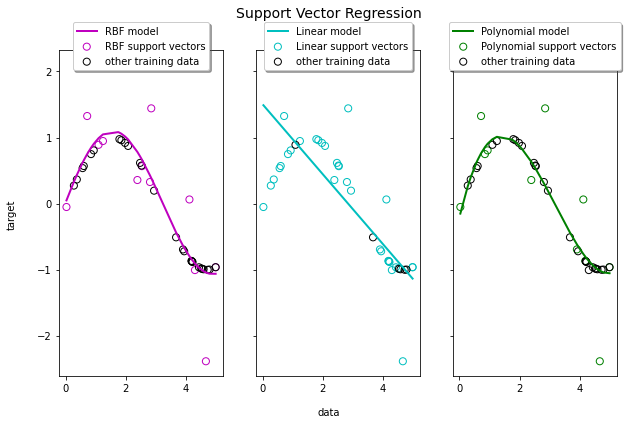

In [5]:
lw = 2
svrs = [svr_rbf, svr_lin, svr_poly]
kernel_label = ["RBF", "Linear", "Polynomial"]
model_color = ["m", "c", "g"]

# 绘制结果
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), sharey=True) 
for ix, svr in enumerate(svrs):
    axes[ix].plot(X, svr.fit(X, y).predict(X), 
                   color=model_color[ix], lw=lw, 
                   label="{} model".format(kernel_label[ix]),)
    axes[ix].scatter(
           X[svr.support_], y[svr.support_],
           facecolor="none", edgecolor=model_color[ix],
           s=50,
           label="{} support vectors".format(kernel_label[ix]),)
    axes[ix].scatter(
           X[np.setdiff1d(np.arange(len(X)), svr.support_)],
            y[np.setdiff1d(np.arange(len(X)), svr.support_)],
           facecolor="none", edgecolor="k",
           s=50,
           label="other training data",)
    axes[ix].legend(loc="upper center", 
                      bbox_to_anchor=(0.5, 1.1), 
                      ncol=1, fancybox=True, shadow=True,)

fig.text(0.5, 0.04, "data", ha="center", va="center")
fig.text(0.06, 0.5, "target", ha="center", va="center", rotation="vertical")
fig.suptitle("Support Vector Regression", fontsize=14)
plt.show()

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>该实验结果验证了核函数选择对SVR性能的决定性影响，为金融时序预测、传感器信号处理等场景提供了典型范例。进一步研究可结合SHAP值分析特征重要性，或尝试混合核函数提升复杂数据拟合能力。
</p>

#### <font color='blue' >5.5.4.3  异常值检测</font>

<font color='red'>支持向量机方法不仅可用于分类、回归，还可用于异常值检测</font>。关于异常值检测在数据预处理阶段已经进行了详细的讨论。One-class SVM是一种无监督学习方法，学习用于异常值检测的决策函数，将新数据分类为与训练集相似或不同。在此，通过例5-22展示如何使用One-Class SVM类实现异常值检测。

**例5-22：非线性核（RBF）One-class SVM。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
   如何使用One-Class SVM类实现异常值检测。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
   1.数据生成<br />
   2.模型训练<br />
   3.预测<br />  
   4.可视化<br />
</details>

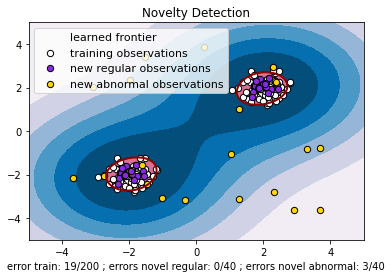

In [4]:
import matplotlib.font_manager
import matplotlib.pyplot as plt
import numpy as np

from sklearn import svm

xx, yy = np.meshgrid(np.linspace(-5, 5, 500), np.linspace(-5, 5, 500))

X = 0.3 * np.random.randn(100, 2)
X_train = np.r_[X + 2, X - 2]  # 生成训练数据
X = 0.3 * np.random.randn(20, 2)
X_test = np.r_[X + 2, X - 2]  # 生成一些常规的新观测值
# 生成一些异常的新观测值
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

clf = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
clf.fit(X_train)  # 拟合模型
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
y_pred_outliers = clf.predict(X_outliers)
n_error_train = y_pred_train[y_pred_train == -1].size
n_error_test = y_pred_test[y_pred_test == -1].size
n_error_outliers = y_pred_outliers[y_pred_outliers == 1].size

# 绘制直线、点和与平面最近的矢量
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.title("Novelty Detection")
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu)
a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="darkred")
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors="palevioletred")

s = 40
b1 = plt.scatter(X_train[:, 0], X_train[:, 1], c="white", s=s, edgecolors="k")
b2 = plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet", s=s, edgecolors="k")
c = plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="gold", s=s, edgecolors="k")
plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.legend(
    [a.collections[0], b1, b2, c],
    ["learned frontier", "training observations", "new regular observations", "new abnormal observations"],
    loc="upper left",
    prop=matplotlib.font_manager.FontProperties(size=11),
)
plt.xlabel("error train: %d/200 ; errors novel regular: %d/40 ; errors novel abnormal: %d/40" % (n_error_train, n_error_test, n_error_outliers))
plt.show()

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>代码通过单类支持向量机（One-Class SVM）模型实现了异常检测，能够识别训练数据中的正常数据和异常数据，并对新的观测值进行分类。
可视化结果直观地展示了模型的决策边界和数据分布，帮助理解模型的性能和行为。
通过统计错误分类的数量，可以评估模型在训练数据、测试数据和异常数据上的性能，为进一步优化模型提供参考。
</p>

#### <font color='blue' >5.5.4.4  核函数</font>

在Scikit-learn中，通过<font color='red'>kernel</font>参数指定不同的核，其取值可以是以下任意一种。

（1）linear:$\left\langle x,x^{\prime}\right\rangle$。

（2）polynomial: $\left(\gamma\langle x,x^{\prime}\rangle+r\right)^d$，其中，$\mathrm{d}$由参数degree指定，$\mathrm{r}$由参数coef0指定。

（3）rbf: $\exp\left(-\gamma\left\|x-x^{\prime}\right\|^2\right)$，其中，$γ$由参数gamma指定，其一定大于0。

（4）sigmoid: $\tanh\left(\gamma\left\langle x,x^{\prime}\right\rangle+r\right)$ ，其中$\mathrm{r}$由参数coef0指定。

In [24]:
import matplotlib.font_manager
import matplotlib.pyplot as plt
import numpy as np

from sklearn import svm
linear_svc = svm.SVC(kernel='linear')
linear_svc.kernel

'linear'

In [23]:
rbf_svc = svm.SVC(kernel='rbf')
rbf_svc.kernel

'rbf'

  ><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>当使用RBF核训练一个支持向量机时，必须仔细考虑两个参数：<font color='red'>C和gamma。</font>参数C是样本正确分类与决策函数间隔最大化之间的折中。当设置较大的C值时，决策函数更倾向于正确地对所有训练点进行分类，可以接受较小的间隔。当设置较小的C值时，将以训练准确性为代价，鼓励更大的间隔，从而实现更简单的决策函数。
</p>

  参数C和gamma的正确选择对支持向量机的性能是至关重要的。建议使用GridSearchCV，其中，C和gamma按指数间隔排列，以选择好的参数值。

**例5-23：RBF参数gamma和C的影响。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
  参数C在支持向量机中表现为正则化参数。gamma参数定义了单个训练样本的影响达到的程度，低值表示“远”，高值表示“近”。gamma参数可以看作由模型选择作为支持向量的样本的影响半径的倒数
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 数据准备<br /> 
    2. 参数搜索<br /> 
    3. 模型训练<br /> 
    4. 可视化<br /> 

</details>

In [1]:
import numpy as np
from matplotlib.colors import Normalize

class MidpointNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

from sklearn.datasets import load_iris

iris = load_iris()  # 加载数据集
X = iris.data
y = iris.target

  为了决策函数的可视化，这里只保留X中的前两个特征，并对数据集进行子采样，只保留两个类，使其成为二分类问题。

In [2]:
X_2d = X[:, :2]
X_2d = X_2d[y > 0]
y_2d = y[y > 0]
y_2d -= 1

针对支持向量机训练用的数据进行缩放通常是一个好主意。在例5-23中，对所有数据进行缩放，而不仅在训练集上拟合转换，还将其应用于测试集。

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_2d = scaler.fit_transform(X_2d)

初始搜索中设置以10为基数的对数网格通常是有用的。如果以2为基数，则可以实现更精细的微调，但时间成本要高得多。

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC

C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
grid.fit(X, y)  # 训练分类器

print("The best parameters are %s with a score of %0.2f" % (grid.best_params_, grid.best_score_))


The best parameters are {'C': 1.0, 'gamma': 0.1} with a score of 0.97


现在需要为这个二维数据版本中的所有参数拟合分类器（这里使用一个较小的参数集，因为训练需要一段时间）

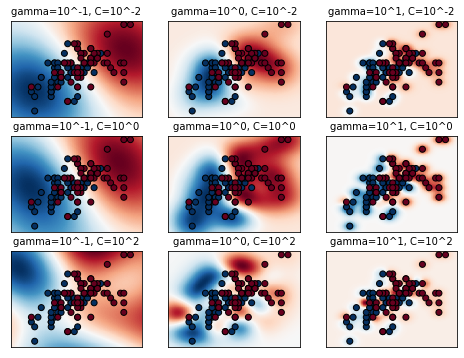

In [7]:
C_2d_range = [1e-2, 1, 1e2]
gamma_2d_range = [1e-1, 1, 1e1]
classifiers = []
for C in C_2d_range:
    for gamma in gamma_2d_range:
        clf = SVC(C=C, gamma=gamma)
        clf.fit(X_2d, y_2d)
        classifiers.append((C, gamma, clf))

# 参数效果的可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
for k, (C, gamma, clf) in enumerate(classifiers):
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])  # 评估决策函数，以网络化
    Z = Z.reshape(xx.shape)

    # 可视化这些参数的决策函数
    plt.subplot(len(C_2d_range), len(gamma_2d_range), k + 1)
    plt.title("gamma=10^%d, C=10^%d" % (np.log10(gamma), np.log10(C)), size="medium")

    # 可视化参数在决策函数上的效果
    plt.pcolormesh(xx, yy, -Z, cmap=plt.cm.RdBu)
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=plt.cm.RdBu_r, edgecolors="k")
    plt.xticks(())
    plt.yticks(())
    plt.axis("tight")

scores = grid.cv_results_["mean_test_score"].reshape(len(C_range), len(gamma_range))

在例5-23的第一张图中展示了各种gamma和C参数值对一个分类问题的决策函数的影响的可视化结果。为了便于显示，该简化的分类问题仅涉及2个输入特征和2个可能的目标类别。请注意，对于具有更多输入特征或目标类的问题，这种绘图是不可能的。 模型的行为对gamma参数非常敏感。该图的第1列，当gamma非常小时，模型过于受限，无法捕捉数据的复杂性或“形状”。任何选定的支持向量的影响区域都将包括整个训练集。所得到的模型类似于具有一组超平面的线性模型，该超平面分离任何两类别的高密度中心。该图的第2列对应gamma的中间值，可以在例5-23的第二张图中看到，在C和gamma的对角线上可以找到好的模型。通过增加正确分类每个点的重要性（较大的C值），可以使平滑模型（较大的gamma值）变得更加复杂。该图的第3列，如果gamma太大，则支持向量的影响区域的半径仅包括支持向量本身，并且用C进行的任何正则化都不能防止过拟合。 另外，从该图中还可以观察到，对于gamma的一些中间值，当C变得非常大时，可以得到性能相同的模型。这表明支持向量集不再发生变化。RBF核的半径单独起到良好的结构正则化项的作用。此时，进一步增大C并没有帮助，这可能是因为没有更多的违规训练点（在边界内或分类错误），或者至少找不到更好的解决方案。当得分相等时，使用较小的C值可能是有意义的，因为非常大的C值通常会增加拟合时间。另外，较小的C值通常导致更多的支持向量，这可能增加预测时间。因此，减小C值是拟合时间和预测时间之间的一种权衡。

验证精度作为gamma和C的函数，绘制其热力图。验证精度得分被编码为热力图中的颜色，热力图的颜色从暗红色到亮黄色不等。由于最感兴趣的分数均位于0.92到0.97的范围内，因此使用自定义归一化函数<font color='red'>MidpointNormalize()</font>将中点设置为0.92，以便更容易地可视化感兴趣范围内的得分的微小变化，同时不会将所有低的得分折叠为相同的颜色。

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>该实验揭示了RBF-SVM参数优化的本质规律：gamma控制模型对数据结构的捕捉能力，C调节模型复杂度与泛化能力的平衡，两者的协同作用形成最优解空间的对角分布特征。
</p>

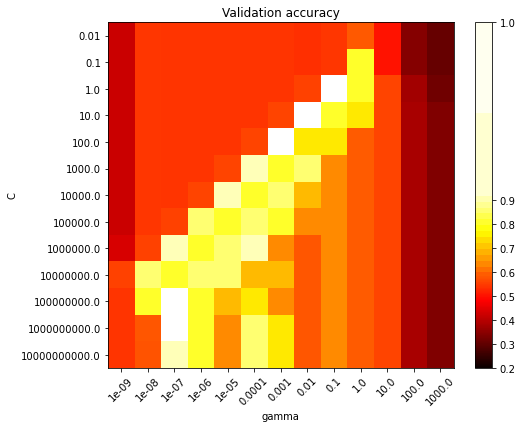

In [8]:
plt.figure(figsize=(8, 6))
plt.subplots_adjust(left=0.2, right=0.95, bottom=0.15, top=0.95)
plt.imshow(scores, interpolation="nearest", cmap=plt.cm.hot, norm=MidpointNormalize(vmin=0.2, midpoint=0.92))
plt.xlabel("gamma")
plt.ylabel("C")
plt.colorbar()
plt.xticks(np.arange(len(gamma_range)), gamma_range, rotation=45)
plt.yticks(np.arange(len(C_range)), C_range)
plt.title("Validation accuracy")
plt.show()

例5-23的第二张图为分类器的交叉验证精度热图，它是C和gamma的函数。在例5-23中，为了展示，探索了一个相对较大的网格。在实践中，从$10^-3$到$10^3$的对数网格通常就足够了。如果最优参数位于网格的边界上，则可以在随后的搜索中沿该方向做进一步扩展。  还应注意到，得分的微小差异是由交叉验证程序的随机划分造成的。可以通过以计算时间为代价增加CV迭代次数n_splits来平滑这些杂散变化。增加C_range和gamma_range步数量将提高超参数热图的分辨率。另外，这里还通过Utility类将热图的中点移动到感兴趣的值附近。

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>该实验为超参数优化提供了典型范式：通过热图直观揭示参数交互规律，结合对数网格的全局覆盖与局部精细化策略，可系统性地逼近最优解。实际应用中建议结合贝叶斯优化替代全网格搜索，以进一步提升调参效率
</p>

### <font color='blue' >5.5.5  算法小结</font>

支持向量机通过使用一个被称为核函数的技巧扩展到非线性问题，而该算法本质上就是计算两类被称为支持向量的观测数据之间的距离。支持向量机算法寻找的决策边界是最大化两类样本间隔的边界，因此支持向量机又被称为最大间距分类器。

支持向量机的优/缺点。

优点：
- ①支持向量机在高维空间中有效，即在维度数大于样本数量的情况下有效；
- ②在决策函数中使用支持向量，因此支持向量机具有内存效率；
- ③可以为决策函数指定不同的核函数，核函数可以是通用核，也可以是自定义核；
- ④最终的决策函数只由少数的支持向量确定，计算的复杂性取决于支持向量的数目，而不是样本空间的维度数，这在某种意义上避免了“维数灾难”。

缺点：
- ①如果特征数量远大于样本数量，则在选择核函数和正则化项时，避免过度拟合是至关重要的；
- ②支持向量机并没有直接提供概率估计，这些估计是使用费时的五折交叉验证计算得到的；
- ③训练时间较长，时间复杂度为O($N^2$),其中N为训练样本数量；
- ④当采用核函数技巧时，如果需要存储核矩阵，则支持向量机方法的空间复杂度为O($N^2$)；
- ⑤在模型预测时，预测时间与支持向量的数量成正比。当支持向量的数量较大时，预测时间较长。因此，支持向量机目前只适合小批量样本任务，无法适应百万级甚至上亿级样本任务。

# <font color='blue' >进阶C  对偶问题</font>

## <font color='blue' >C.1  拉格朗日乘子法</font>

### <font color='blue' >C.1.1  等式约束优化问题</font>

使用<font color='red'>拉格朗日乘子法</font>求解的等式约束优化问题为

<div style="text-align: center;">$
\mathrm{min}f\left(x_{1},x_{2},\cdots,x_{n}\right)\mathrm{s.t.}h_{k}\left(x_{1},x_{2},\cdots,x_{n}\right)=0,k=1,2,\cdots,l
$

记 $
L\left(x,\lambda\right)=f\left(x\right)+\sum_{k=1}^{l}\lambda_{k}h_{k}\left(x\right)
$ 为拉格朗日函数，其中λ为拉格朗日乘子，$λ^k$没有非负要求。$L(x,\lambda)$关于λ和$λ^k$求导取0是求得可能的极值点的必要条件，如式（5-25）所示。

<div style="text-align: center;">$\begin{cases} \frac{\partial L}{\partial x_{i}}=0 & i=1,2,\cdots,n \\ \\ \frac{\partial L}{\partial\lambda_{k}}=0 & k=1,2,\cdots,l & \end{cases}$

具体是否为极值点需要根据问题本身的具体情况进行检验

等式约束下的拉格朗日乘子法引入了l个拉格朗日乘子，将$x_i$与$λ^k$一视同仁，把$λ^k$也看作优化变量，那共有个(n+l)优化变量。

### <font color='blue' >C.1.2  不等式约束优化问题</font>

当我们面对的是不等式优化问题时，需要将不等式约束条件转变为等式约束条件，引入松弛变量，并将其视为待优化变量。

下面以支持向量机的不等式约束优化问题为示例进行求解：

<div style="text-align: center;">$\min f(\boldsymbol{w})=\frac{1}{2}\|\boldsymbol{w}\|^{2}\mathrm{s.t.}g_{ı}(\boldsymbol{w})=1-y_{ı}(\boldsymbol{w}^{ı}x_{ı}+b)\leqslant0$

在式（5-26）中，通过引入松弛变量$a_{i}^{2}$得到 $h_{\iota}\left(w,\alpha_{\iota}\right)=g_{\iota}\left(w\right)+\alpha_{\iota}^{2}=0$，引入平方项$a_{i}^{2}$的主要原因是不再引入新的约束条件。如果引入任意数$a_i$，则必须保证$a_i$≥0，只有这样才能保证 $h_{i}(w,\alpha_{i})=0$，这不符合我们的意愿。

由此，将式（5-26）中的不等式约束转化为等式约束，可得拉格朗日函数，如式（5-27）所示，其中 $f(w)=\frac{1}{2}\|w\|^{2}$

<div style="text-align: center;">$L\left(w,\lambda,\alpha\right)=f\left(w\right)+\sum_{i=1}^{n}\lambda_{i}h_{i}\left(w\right)=f\left(w\right)+\sum_{i=1}^{n}\lambda_{i}\left[g_{i}\left(w\right)+d_{i}^{2}\right]\quad\lambda_{i}\geq0$

由等式约束优化问题极值的必要条件对式（5-27）进行求解，得以下联立方程：

<div style="text-align: center;">$\begin{cases} \frac{\partial L}{\partial w_{i}}=\frac{\partial f}{\partial w_{i}}+\sum_{i=1}^{n}\lambda_{i}\frac{\partial g_{i}}{\partial w_{i}}=0 & i=1,2,\cdots,n \\ \frac{\partial L}{\partial a_{i}}=2\lambda_{i}a_{i}=0 & k=1,2,\cdots,l \\ \frac{\partial L}{\partial\lambda_{i}}=g_{i}\left(w\right)+d_{i}^{2}=0 & i=1,2,\cdots,n \\ \lambda_{i}\geq0 & k=1,2,\cdots,l & \end{cases}$

在式（5-28）中，为什么取$λ_i$≥0呢？这可以通过几何性质来解释，有兴趣的读者可以查询其证明。

式（5-28）告诉了我们什么事情呢？直观来讲就是，支持向量 $g_{\iota}\left(w\right)=0$，因此 $λ_i$>0 即可。而对于其他向量 $g_{\iota}(w)<0$，$λ_i$=0。

原优化问题变换为

<div style="text-align: center;">$L\left(w,\lambda,\alpha\right)=f\left(w\right)+\sum_{i=1}^{n}\lambda_{i}\left[g_{i}\left(w\right)+\alpha_{i}^{2}\right]=f\left(w\right)+\sum_{i=1}^{n}\lambda_{i}g_{i}\left(w\right)+\sum_{i=1}^{n}\lambda_{i}\alpha_{i}^{2}$

由于 $\sum_{i=1}^{n}\hat{A}_{i}a_{i}^{2}$≥0，因此将极小化式（5-30）转换为 $\mathrm{min}L\left(w,\lambda\right)$。

<div style="text-align: center;">$L\left(w,\lambda\right)=f\left(w\right)+\sum_{i=1}^{n}\lambda_{i}g_{i}\left(w\right)$

假设找到了最优参数，使得目标函数取得最小值p，即 $\frac{1}{2}\|w\|^{2}=p$。根据$λ_i$≥0，可知 $\hat{\sum}_{i=1}\lambda_{i}g_{i}(w)\leq0$，因此 $L(w,\lambda)\leq p$。为了找到最优参数λ，使得$L(w,\lambda)$接近p，原问题可转换为 $\underset{\lambda}{max}L(w,\lambda)$。

故最优化问题转换为

<div style="text-align: center;">$\underset {w}{min}  \underset{\lambda}{max}L(w,\lambda)\mathrm{s.t.}\lambda\geq0$

式（5-31）的对偶问题实质上就是将 $\underset {w}{min}  \underset{\lambda}{max}L(w,\lambda)\mathrm{s.t.}\lambda\geq0$ 变换为 $\underset{\lambda}{max}\underset {w}{min}L(w,\lambda)$s.t.$λ_i$≥0 假设函数$f$满足 $\min\max f\geqslant\max\min f$ 即从最大值中挑出来的最小值要比从最小值中挑出来的最大值大，这是弱对偶关系；强对偶关系是指等号成立，即 $\min\max f=$$\max\min f$

如果$f$是凸优化问题，则强对偶性成立，而前面描述的KKT条件是强对偶性的充要条件。

## <font color='blue' >C.2  支持向量机优化</font>

已知支持向量机优化问题为

<div style="text-align: center;">$\underset {w}{min}\frac{1}{2}\left\|\mathbf{w}\right\|^{2}\mathrm{s.t.}\mathbf{g}_{i}\left(\mathbf{w},b\right)=1-\mathbf{y}_{i}\left(\mathbf{w}^{\mathbf{r}}\mathbf{x}_{i}+b\right)\leq0i=1,2,\cdots,n$

线性可分的支持向量机的求解步骤如下。
步骤1，构造拉格朗日函数：

<div style="text-align: center;">$\underset {w,b}{min}\underset{\lambda}{max}L\left(w,b,\lambda\right)=\frac{1}{2}\left\|w\right\|^{2}+\sum_{i=1}^{n}\lambda_{i}\left[1-y_{i}\left(w^{r}x_{i}+b\right)\right]\mathrm{s.t.}\lambda\geq0$

步骤2，利用强对偶性将上式转化为

<div style="text-align: center;">$\underset{\lambda}{max}\underset {w,b}L(w,b,\lambda)$

目标函数$L(\boldsymbol{w},b,\lambda)$关于参数w和求偏导数b并取值为0，可得

<div style="text-align: center;">$\frac{\partial L}{\partial w}=w-\sum_{i=1}^{n}\hat{A}_{i}x_{i}y_{i}=0$

<div style="text-align: center;">$\frac{\partial L}{\partial b}=\sum_{i=1}^{n}\hat{\lambda}_{i}y_{i}=0$

可得

<div style="text-align: center;">$w=\sum_{i=1}^{n}\lambda_{i}x_{i}y_{i}$

<div style="text-align: center;">$\sum_{i=1}^{n}\lambda_{i}y_{i}=0$

将上述结果代到目标函数中，可得

<div style="text-align: center;">$\begin{aligned} L(\boldsymbol{w},b,\lambda) & =\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}\lambda_{j}y_{i}y_{j}\left(x_{i}x_{j}\right)+\sum_{j=1}^{n}\lambda_{i}-\sum_{i=1}^{n}\lambda y_{i}\left(\sum_{j=1}^{n}\lambda_{j}y_{j}\left(x_{i}x_{j}\right)+b\right) \\ & =\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}\lambda_{j}y_{i}y_{j}\left(x_{i}x_{j}\right)+\sum_{j=1}^{n}\lambda_{i}-\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}y_{i}\lambda_{j}y_{j}\left(x_{i}x_{j}\right)-\sum_{j=1}^{n}\lambda_{i}y_{i}b \\ & =\sum_{j=1}^{n}\lambda_{i}-\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}y_{i}\lambda_{j}y_{j}(x_{i}x_{j}) \end{aligned}$

即<div style="text-align: center;">$\min_{v,s}L\left(w,b,\lambda\right)=\sum_{j=1}^{n}\lambda_{i}-\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}y_{i}\lambda_{j}y_{j}\left(x_{i},x_{j}\right)$

步骤3，由步骤2中的式（5-32）可得

<div style="text-align: center;">$\underset{\lambda}{max}\left[\sum_{j=1}^{n}\lambda_{i}-\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}y_{i}\lambda_{i}y_{i}\left\{x_{i}x_{i}\right\}\right]\quad\mathrm{s.t.}\sum_{i=1}^{n}\lambda_{i}y_{i}=0,\quad\lambda_{i}\geq0?$

式（5-34）是一个二次规划问题，问题规模正比于训练样本数。常用序列最小优化算法（Sequential Minimal Optimization，SMO）算法进行求解，其核心思想是每次只优化少量参数，其他参数保持不变，仅求解目标函数关于当前正优化参数的极值，SMO算法的细节超出本书范围，读者可参阅相关资料。

步骤4，由步骤2中的式（5-33），有。由步骤3求得λ代入，可得w，已知$λ_i$>0对应的样本点是支持向量，满足方程$y_{s}\left(w^{1}x_{s}+b\right)=1$，方程两边同乘$y_s$，可得。因为=1，所以有 $y_{s}^{2}\left\{w^{1}x_{s}+b\right\}=y_{s}$。因为$y_{s}^{2}$,所以有

<div style="text-align: center;">$b=y_{s}-w^{1}x_{s}$

为了使支持向量机更具鲁棒性，可以关于所有的支持向量求平均值：

<div style="text-align: center;">$b=\frac{1}{|S|}\sum_{s\in S}(y_{s}-wx_{s})$

步骤5，求得w和b后，构造最大分离超平面 $w^{1}x+b=0$ 及相应的分类决策函数：<div style="text-align: center;">$f(x)=\mathrm{sign}(w^{1}x+b)$

其中，sign()为阶跃函数:

$\mathrm{sign}\left(x\right)= \begin{cases} -1 & x<0 \\ 0 & x=0 \\ 1 & x>0 & \end{cases}$

将新样本点代入决策函数中，即可得到样本的分类。

## <font color='blue' >进阶D  软间隔情况下的最优化问题及其求解</font>

步骤1，构造拉格朗日函数：

<div style="text-align: center;">$\begin{aligned} & \min_{w,b,\xi}\max_{\lambda,\mu}L(w,b,\xi,\lambda,\mu) \\ & =\frac{1}{2}\left\|w\right\|^{2}+C\sum_{i=1}^{m}\xi_{i}+\sum_{i=1}^{n}\lambda_{i}\left[1-\xi_{i}-y_{i}\left(w^{T}x_{i}+b\right)\right]-\sum_{i=1}^{n}\mu_{i}\xi_{i}\mathrm{s.t.}\lambda_{i} \\ & \geq0,\mu_{i}\geq0 \end{aligned}$

其中，$λ_i$和$u_i$是拉格朗日乘子；w、b和$\xi_i$是问题的主参数

根据强对偶性，将上式转化为

<div style="text-align: center;">$\underset {\lambda,\mu}{max}\underset {w,b,\xi}{min}L(w,b,\xi,\lambda,\mu)$

步骤2，目标函数 $L(\boldsymbol{w},b,\xi,\lambda,\mu)$ 分别关于主参数w、b和$\xi_i$和求偏导数并取值为0，可得

<div style="text-align: center;">$w=\sum_{i=1}^{n}\lambda_{i}x_{i}y_{i}$

<div style="text-align: center;">$\sum_{i=1}^{n}\lambda_{i}y_{i}=0$

<div style="text-align: center;">$\hat{\lambda}_{l}+\mu_{l}=C$

将上述等式带入拉格朗日函数中，可得

<div style="text-align: center;">$\underset {w,b,\xi}{min}L\left(\mathbf{w},b,\xi,\lambda,\mu\right)=\sum_{j=1}^{n}\lambda_{i}-\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}y_{i}\lambda_{j}y_{j}\left(x_{i},x_{j}\right)$

最小化问题中只有λ没有u，因此现在只需最大化λ即可

<div style="text-align: center;">$\underset{\lambda}{max}\left[\sum_{j=1}^{n}\lambda_{i}-\frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\lambda_{i}y_{i}\lambda_{j}y_{i}(x_{i}x_{i})\right]\quad\mathrm{s.t.}\sum_{j=1}^{n}\lambda_{i}y_{i}=0,\quad\lambda_{i}\geq0,\quad C-\lambda_{i}-\xi_{i}=0$

可以看到，软间隔和硬间隔中的最大化问题是一样的，只是多了约束条件。同样，采用SMO算法求解得到拉格朗日乘子λ

步骤3：

<div style="text-align: center;">$w=\sum_{i=1}^{n}\lambda_{i}x_{i}y_{i}$

<div style="text-align: center;">$b=\frac{1}{|S|}\sum_{s\in S}(y_{s}-wx_{s})$

通过上面两个式子求出w和b，最终可得分离超平面 $w^{T}x+b=0$。

注意：在间隔内的那部分样本点是不是支持向量呢？由求参数w的上式可看出，只要是$λ_i$＞0点都能够影响超平面，因此在间隔内的那部分样本点都是支持向量。

## <font color='blue' >5.6　决策树</font>

决策树是一种基本的分类与回归方法，本节主要讨论用于分类的决策树。为了更深入地理解决策树，需要学习一点信息论知识。

### <font color='blue' >5.6.1  信息论知识</font>

本节主要引入了信息熵、条件熵、相对熵及互信息的概念及它们之间的关系。

1．信息熵

定义5-3：设离散型随机变量X的取值有$x_{1},x_{2},\ldots,x_{n}$，其发生概率分别为$p_{1},p_{2},\ldots,p_{n}$，则信息熵定义为<div style="text-align: center;">$H\left(X\right)=-\sum_{i=1}^{\hat{\boldsymbol{\Sigma}}}p_{i}\mathrm{log}(p_{i})$

一般对数的底数是2，当然也可以换成e，当对数的底数为2时，信息熵的单位为bit，信息熵也称香农熵。当对数的底数不为2而是其他大于2的整数时，称信息熵为-进制熵，记为$H_{r}\left(X\right)$，它与信息熵的变换公式为<div style="text-align: center;">$H_{r}\left(X\right)=H\left(X\right)/\log(r)$

信息熵用来描述信源的不确定性，概率越大，可能性越大，但是信息量越小，不确定性越小，熵越小。

2．条件熵

设随机变量$(X,Y)$具有联合概率分布 $P(X=x_{i},Y=y_{j})=p_{y},i=1,2,\cdots,n,j=1,2,\cdots,m$，条件熵 $H(Y|X)$ 表示在已知随机变量 $\mathrm{X}$ 的条件下随机变量 $\mathrm{Y}$ 的不确定性。可以这样理解条件熵：$(X,Y)$ 发生所包含的熵减去 $\mathrm{X}$ 单独发生的熵就是在 $\mathrm{X}$ 发生的前提下，$\mathrm{Y}$ 发生新带来的熵，即 $H\left(Y|X\right)=H\left(X,Y\right)-H\left(X\right)$。

条件熵的推导过程如下：

<div style="text-align: center;">$\begin{aligned} H\left(X,Y\right)-H\left(X\right) & =-\sum_{i,j}p\left(x,y\right)\log p\left(x,y\right)+\sum_{i}p\left(x\right)\log p\left(x\right) \\ & =-\sum_{i,j}p\left(x,y\right)\log p\left(x,y\right)+\sum_{i}\left(\sum_{i}p\left(x,y\right)\right)\log p\left(x\right) \\ & =-\sum_{i,j}p\left(x,y\right)\log p\left(x,y\right)+\sum_{i,j}p\left(x,y\right)\log p\left(x\right) \\ & =-\sum_{i,j}p\left(x,y\right)\mathrm{log}\frac{p\left(x,y\right)}{p\left(x\right)} \\ & =-\sum_{i,j}p\left(x,y\right)\log p\left(y\mid x\right) \end{aligned}$

3．相对熵

相对熵描述使用概率分布$Q(x)$拟合真实分布$P(x)$时产生的信息损耗，其中，$P(x)$和$Q(x)$是随机变量$Q(x)$的两个概率分布，$P(x)$关于$Q(x)$的相对熵定义为

<div style="text-align: center;">$D(P\|Q)=\sum_{i}P(x)\mathrm{log}\frac{P(x)}{Q(x)}$

由此可见，相对熵表示两个概率分布$Q(x)$和$P(x)$差异的非对称性度量，也称为KL散度。KL散度不是对称的，即$D(P\|Q)\neq D(Q\|P)$。

在信息理论中，相对熵用于衡量两个概率分布之间的差异。式（5-35）的意义就是求 与之间的对数差在上的期望值，即

<div style="text-align: center;">$\mathrm{KL}(P\|Q)=-\sum_{sex}P(x)\mathrm{log}\frac{1}{P(x)}+\sum_{sex}P(x)\mathrm{log}\frac{1}{Q(x)}=\sum_{sex}P(x)\mathrm{log}\frac{P(x)}{Q(x)}$。

4．互信息

两个随机变量$\mathrm{X}$和$\mathrm{Y}$的互信息定义为$\mathrm{X}$和$\mathrm{Y}$的联合分布与独立分布乘积的相对熵，即

<div style="text-align: center;">$I\left(X,Y\right)=KL\left(P\left(X,Y\right)\|P(X)P(Y)\right)$

根据相对熵的定义，互信息可表示为

<div style="text-align: center;">$I(X,Y)=\sum_{x,y}P(x,y)\log\left[\frac{P(x,y)}{P(x)P(y)}\right]$

将其代入下式：

$\begin{aligned} H(Y)-I(X,Y) & =-\sum_{,}P(y)\mathrm{log}P(y)-\sum_{i,j}P(x,y)\mathrm{log}\left[\frac{P(x,y)}{P(x)P(y)}\right] \\ & =-\sum_{y}\left(\sum_{z}P(x,y)\right)\mathrm{log}P(y)-\sum_{z,y}P(x,y)\mathrm{log}\left[\frac{P(x,y)}{P(x)P(y)}\right] \\ & =-\sum_{x,y}P(x,y)\mathrm{log}P(y)-\sum_{x,y}P(x,y)\mathrm{log}\left[\frac{P(x,y)}{P(x)P(y)}\right] \\ & =-\sum_{x,y}P(x,y)\log\left[\frac{P(x,y)}{P(x)}\right] \\ & =-\sum_{i,y}P(x,y)\mathrm{log}P(y\mid x) \\ & =H\left(Y|X\right) \end{aligned}$

最后可得 $I\left(X,Y\right)=H\left(Y\right)-H\left(X\mid Y\right)$

前面介绍了熵和互信息的概念，那么，它们之间的关系是什么样的呢？

5．熵和互信息之间的关系

联立求解下述条件熵的两个等式：

<div style="text-align: center;">$\begin{cases} H\left(Y|X\right)=H\left(Y\right)-I\left(X,Y\right) \\ H\left(Y|X\right)=H\left(X,Y\right)-H\left(X\right) & \end{cases}$

由条件熵的定义可得下面两个不等式：

<div style="text-align: center;">$H\left(X|Y\right)\leqslant H\left(X\right)$

<div style="text-align: center;">$H(Y|X)\leqslant H(Y)$

这两个不等式告诉我们，对于一个与$X$相关的随机变量$Y$，只要知道一点关于$Y$的信息,那么$X$不确定性就会降低。这里借助图5-39的韦恩图表示这些熵和互信息之间的关系。

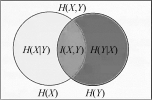

<div style="text-align: center;">图5-39  熵和互信息之间的关系</div>

现实生活中我们可能会面临各种抉择。例如，图5-40就描述了一个相亲的抉择过程，可以发现该过程是一个树状模型。(年龄,长相,收入)是描述一个人的特征向量，我们做出的抉择都是基于特征分量在一个节点处进一步解析成多个新的节点。

根据节点所处的位置，一棵决策树通常由根节点、叶节点和内部节点组成；其中根节点是树顶端的节点，如图5-40中的“年龄”特征分量；叶节点是树底端的节点，描述了本决策过程的结果，即“见”还是“不见”这两个类别；除了叶子节点，其他节点都是内部节点，每个内部节点均表示在一个特征分量上的测试，每个分支代表一个测试输出。

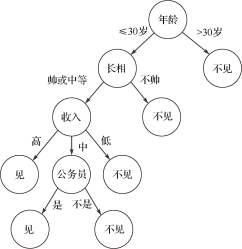

下面以(天气,温度,风级)为特征向量，结论是“是否打球”的一个实例来讲述决策树，如表5-2所示。

<div style="text-align: center;">表5-2  “是否打球”实例</div>

| 日期 | 天气 | 温度 | 风级 | 打球 |
|----|----|----|----|----|
| 1  | 晴 | 高 | 弱 | 否 |
| 2  | 晴 | 高 | 强 | 否 |
| 3  | 阴 | 高 | 弱 | 是 |
| 4  | 雨 | 高 | 弱 | 是 |
| 5  | 雨 | 正常 | 强 | 是 |
| 6  | 雨 | 正常 | 强 | 否 |
| 7  | 阴 | 正常 | 强 | 是 |
| 8  | 晴 | 高 | 弱 | 否 |

| 日期 | 天气 | 温度 | 风级 | 打球 |
|------|------|------|------|------|
| 9    | 晴   | 正常  | 弱   | 是   |
| 10   | 雨   | 正常  | 弱   | 是   |
| 11   | 晴   | 正常  | 强   | 是   |
| 12   | 阴   | 高   | 强   | 是   |
| 13   | 阴   | 正常  | 弱   | 是   |
| 14   | 雨   | 高   | 强   | 否   |

如图5-41所示，第一层根节点以天气作为分类依据，有3个分支。共14个样本，依据是否打球被分成9是/5否，总体信息熵为

<div style="text-align: center;">$H_{0}=-\left[\left(\frac{5}{14}\right)log\left(\frac{5}{14}\right)+\left(\frac{9}{14}\right)log\left(\frac{9}{14}\right)\right]\approx0.9403$

第二层中的第一个分支“晴”节点处共5个样本，依据是否打球被分为2是/3否，信息熵为 $H_{1}=-\left[\left(\frac{2}{5}\right)\mathrm{log}\left(\frac{2}{5}\right)+\left(\frac{3}{5}\right)\mathrm{log}\left(\frac{3}{5}\right)\right]\approx0.9701$

依次类推，在“阴”节点处有4个样本，分为4是/0否，信息熵为 $H_{2}=-\left[\log\left(1\right)\right]=0$

在“雨”节点处有5个样本，分为3是/2否，信息熵为 $H_{3}=-\left[\left(\frac{2}{5}\right)\mathrm{log}\left(\frac{2}{5}\right)+\left(\frac{3}{5}\right)\mathrm{log}\left(\frac{3}{5}\right)\right]=0.9701$

由此，第二层的加权信息熵定义为 $H^{\prime}=\frac{5}{14}H_{1}+\frac{4}{14}H_{2}+\frac{5}{14}H_{3}$

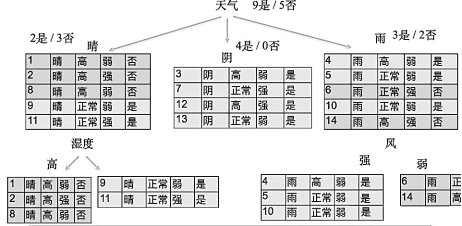

<div style="text-align: center;">图5-41  “是否打球”决策树</div>

规定$H^{\prime}$比$H_{_0}$小，即随着决策的进行，其不确定性要降低，要不然就没有决策的意义了。有效决策肯定要有一个由不确定状态到确定状态的转变。计算求得

$H^{\prime}\approx0.6929<H_0\approx0.9403$，符合这个要求。

事实上，随着分类的进行，越来越多的信息将被知道，总体的熵肯定是会下降的。
同理，在“晴”节点处，湿度作为分类依据，它的两个叶节点的熵均为0，得到决策结果。

因此，决策树采用自顶向下的递归方法，其基本思想是以信息熵为度量构造一棵熵值下降最快的树，叶节点处的熵值为0，此时每个叶节点中的实例都属于同一类。

#### <font color='blue' >5.6.2.1  决策树生成算法</font>

首先，选择一个根节点，选择哪个特征当作根节点呢？在“是否打球”示例中，有天气$f_{1}$、湿度$f_{2}$及风级$f_{3}$三个特征，只能三选一。分别以这3个特征$f_{1}$,$f_{2}$,$f_{3}$为根节点生成3棵树（从第一层到第二层），而究竟选择哪个特征作为根节点有以下三种准则。

1．信息增益与ID3

定义5-4：记$H_{_0}$是一个样本集合$\mathrm{D}$划分前的熵，$H_{1}$是依据某个特征$\mathrm{A}$对其进行划分后的数据子集的加权熵，称$H_{_0}-H_{_1}$为信息增益，也可以表示为$g \begin{pmatrix} {D,A} \end{pmatrix}=H \begin{pmatrix} {D} \end{pmatrix}-H \begin{pmatrix} {D\mid A} \end{pmatrix}=$$I(D,A)$。

在没有选择特征$f_{1}$为根节点前，“是否打球”的信息熵为0.9403。在选择天气为根节点并一分为三后，信息熵下降为0.6936，信息熵下降了0.2467，即信息增益为 0.2467($g(D,f_{1})=H_{0}-H^{\prime}$=0.9403−0.6936=0.2467）

<font color='red'>结论5-1：信息增益的局限在于其偏向取值较多的特征。</font>

结论5-1是显而易见的，样本集合划分前的熵是一定的，当特征的取值较多时，根据此特征划分更容易得到纯度更高的子集，子集划分之后的熵更低，信息增益更大，因此信息增益偏向取值较多的特征。

一种极端情况是假设有一个特征，依据该特征可以将训练集的每个样本划分成一个分支，有n个样本，决策树为n叉树，划分后的熵变为0。此时，信息增益最大。

以信息增益为选择指标生成决策树的算法称为ID3算法。

3．基尼系数与CART

在有$\mathrm{K}$个类别的样本集合$\mathrm{D}$中，一个随机选中的样本被错分的概率是$1-p_{k}$，其中$C_{k}$是$\mathrm{D}$中属于k类别的样本子集$p_{k}=\frac{|C_{k}|}{|D|}$表示随机选中的样本属于k类别的概率。基尼指数（基尼不纯度）是另一种衡量不确定性的指标，其定义如下：

<div style="text-align: center;">$\mathrm{Gini}\left(p\right)=\sum_{k=1}^{x}p_{k}\left(1-p_{k}\right)=1-\sum_{k=1}^{x}p_{k}^{2}$

  当样本属于每个类别的概率都相等，即均为$\mathrm{1/K}$时，基尼系数最大。也就是说，此时的不确定性最大。如果数据集$D$根据特征$A$是否取某一可能值a被分割成$D_{1}$和$D_{2}$两部分，则在给定特征的条件下，$D$的基尼指数为

<div style="text-align: center;">$\mathrm{Gini}\left(D,A\right)=\frac{\left|D_{1}\right|}{\left|D\right|}\mathrm{Gini}\left(D_{1}\right)+\frac{\left|D_{2}\right|}{\left|D\right|}\mathrm{Gini}\left(D_{2}\right)$

容易证明，基尼指数越大，样本的不确定性也越大，特征$A$的区分度越差。在决策树的生成过程中，优先选择基尼指数最小的特征对样本集进行划分，称之为CART算法。

关于基尼系数，有一种说法更直观易懂。比较信息熵定义$H\left(X\right)=-\sum_{i=1}^{\hat{\boldsymbol{\Sigma}}}p_{i}\mathrm{log}(p_{i})$和基尼指数定义，可见，基尼系数是用代替，如图 5-42 所示。

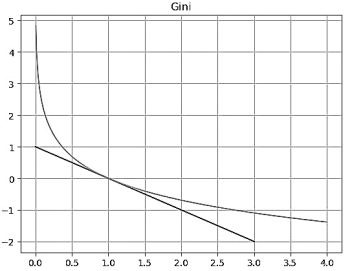

<div style="text-align: center;">图5-42  基尼系数与信息熵</div>

只需查看区间$\begin{bmatrix} 0,1 \end{bmatrix}$上的图像，基尼系数相对于信息熵，就是用近似的切线来代替对数函数。信息熵可以表述不确定性，基尼系数自然也可以，只不过存在一些误差。

CART决策树又称分类回归树，当数据集的因变量为连续性数值时，该算法是一棵回归树，可以用叶节点观测到的均值作为预测值；当数据集的因变量为离散型数值时，该树算法就是一棵分类树。当CART是分类树时，采用基尼系数作为节点分裂的依据；当CART是回归树时，采用MSE作为节点分裂的依据。

#### <font color='blue' >5.6.2.2  决策树评估</font>

假定样本类别数量为$K$，决策树的某个叶节点包含的样本数量为$n$，其中$k$类别的样本数量为$n_{_k},k=1,2,\cdots,K$。这里有两种极端情况，第一种极端情况是某类别样本数量为$n$，其他类别样本数量均为0，即该叶节点中所有样本属于同一类，称该节点为纯节点，其熵为0；第二种极端情况是某叶节点中包含所有类别的样本且各类别样本数量相同，称该节点为均节点，其熵为$\mathrm{1ogK}$。对所有叶节点的熵求和，该值越小，说明决策树分类越准确。

由于各叶节点包含的样本数量不同，因此通常采用加权熵和定义决策树的损失函数。

假设树$T$有$\left|T\right|$个叶节点，某个叶节点$t$上有$N_{_{t}}$个样本，其中$k$类别的样本有$N_{tK}$个，叶节点$t$的熵为$H_{\iota}\left(T\right)=-\sum_{k}\frac{N_{tK}}{N_{t}}\mathrm{log}\frac{N_{tK}}{N_{t}}$,$\alpha\geq0$,则决策树的损失函数为

<div style="text-align: center;">$C\left(T\right)=\sum_{t\in\mathrm{leaf}}N_tH_t\left(T\right)+\alpha\left|T\right|_{t^{\prime}}$

损失函数越小，说明决策树效果越好，损失函数第一项为训练误差，第二项为模型复杂度，用参数$\mathrm{a}$来衡量二者的比重。

#### <font color='blue' >5.6.2.3  决策树过拟合</font>

上述决策树生成算法递归地生成一棵决策树，直到结束划分。那么，什么时候结束呢？有两种情况：<font color='red'>①叶节点内的样本属于同一类；②没有特征可执行进一步的划分。</font>如此得到的决策树通常对训练数据的分类非常精准；但是对于未知数据，其表现较差。原因在于基于训练集构造的决策树过于复杂，易产生过拟合。因需要对决策树进行简化，砍掉多余的分支，提高其泛化能力。

决策树剪枝一般有两种方法：<font color='red'>①预剪枝，在决策树的生成过程中基于贪心策略剪枝，一般会导致局部最优；②后剪枝，在决策树全部生成后剪枝，运算量较大，比较精准。</font>
通过极小化决策树整体的损失函数实现剪枝。由样本完全树$T_{0}$开始，剪枝部分节点得树$T_{1}$；然后剪枝部分节点得树$T_{2}$。依次类推，直到仅剩树根的$T_{k}$。使用验证数据集对这k棵树分别进行评价，选择损失函数最小的树$T_{α}$。

### <font color='blue' >5.6.3  决策树实践</font>

决策树是一种用于分类和回归的非参数<font color='red'>有监督学习方法。</font>该方法的目标是创建一个模型，通过对数据特征进行推断的简单决策规则的学习来预测目标变量值。通常而言，树越深，决策规则就越复杂，模型越合适。

#### <font color='blue' >5.6.3.1  分类</font>

Scikit-learn中的DecisionTreeClassifier是能够在一个数据集上执行多类别分类的类。与其他分类器一样，DecisionTreeClassifier采用两个数组作为输入，一个是稀疏或密集的数组X，其形状为(n_samples, n_features)，用于保存训练样本；另一个是整数值的数组Y，其形状为(n_samples,)，用于存储训练样本的类别标签。这里通过调用构造函数DecisionTreeClassifier()生成模型对象clf，使用其fit(X, Y)方法进行拟合。

In [2]:
from sklearn import tree
X = [[0, 0], [1, 1]]
Y = [0, 1]
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, Y)

拟合后，该模型对象clf可用于预测样本类别。

In [3]:
clf.predict([[2., 2.]])

array([1])

In [4]:
clf.predict_proba([[2., 2.]])

array([[0., 1.]])

DecisionTreeClassifier既能进行二分类（标签为$\begin{bmatrix} -1,1 \end{bmatrix}$），能进行多分类（标签为$\begin{bmatrix} {0,1,\cdots,k-1} \end{bmatrix}$）。下面使用Iris数据集，以此为例来构建并拟合决策树。

In [5]:
from sklearn.datasets import load_iris
from sklearn import tree
iris = load_iris()
X, y = iris.data, iris.target
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

模型训练完成后，可以使用plot_tree()函数绘制树，如图5-43所示。

[Text(0.5, 0.9166666666666666, 'X[2] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.5769230769230769, 0.75, 'X[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.3076923076923077, 0.5833333333333334, 'X[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'X[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'X[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, 'X[0] <= 6.95\ngini = 0.444\nsamples = 3\nvalue = [0, 2, 1]'),
 Text(0.46153846153846156, 0.08333333333333333, 'gini

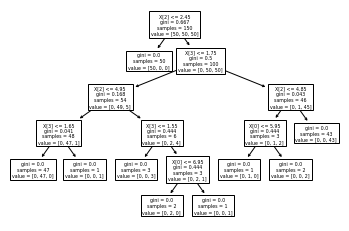

In [6]:
tree.plot_tree(clf)

<div style="text-align: center;">图5-43  Iris数据集决策树</div>

另外，还可以使用export_Graphviz导出器以Graphviz格式导出树。下面在整个iris数据集上训练的决策树以Graphviz格式导出树并将结果保存在输出文件iris.pdf中。

In [11]:
import graphviz 
dot_data = tree.export_graphviz(clf, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("iris")

'iris.pdf'

export_graphviz导出器还有支持美化的各种选项，包括按节点的类别（或回归值）为节点着色，以及根据需要使用显式变量和类名。Jupyter notebook可以自动在线渲染这类绘图，如图5-43所示。

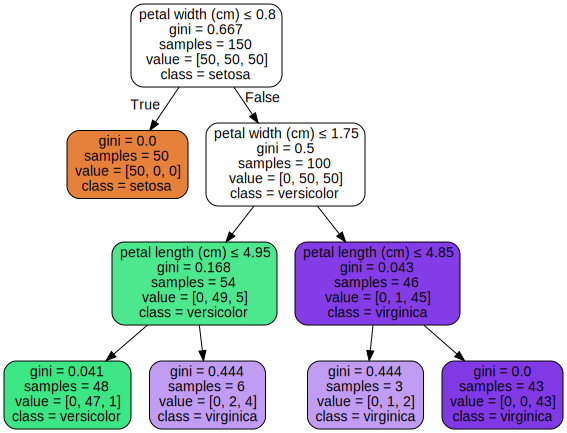

In [16]:
dot_data = tree.export_graphviz(
    clf, 
    out_file=None, 
    feature_names=iris.feature_names,  
    class_names=iris.target_names,  
    filled=True, 
    rounded=True,  
    special_characters=True)  

graph = graphviz.Source(dot_data)
graph

<div style="text-align: center;">图5-43  Iris数据集决策树</div>

或者，也可以使用函数export_text()以文本格式导出树。这种方法不需要安装外部库，而且更紧凑。

In [14]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
iris = load_iris()
decision_tree = DecisionTreeClassifier(random_state=0, max_depth=2)

In [15]:
decision_tree = decision_tree.fit(iris.data, iris.target)
r = export_text(decision_tree, feature_names=iris['feature_names'])
print(r)

|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



上述任务的完整代码整理在例5-24中。这里绘制了在iris数据集的成对特征上训练的决策树的决策面，如图5-44所示。另外，还展示了基于数据集的所有特征构建的模型的树结构，如图5-43所示。

**例5-24：绘制在iris数据集上训练的决策树的决策面。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 例5-24使用了 scikit-learn 库中的 DecisionTreeClassifier 来训练决策树模型，并可视化决策树的决策边界和决策树结构。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 加载数据集<br /> 
    2. 特征组合选择<br /> 
    3. 训练决策树模型<br /> 
    4. 绘制决策边界<br /> 
    4. 绘制决策树结构<br /> 

</details>

首先加载Scikit-learn附带的Iris数据集。

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

显示在所有成对特征上训练的决策树的决策函数。

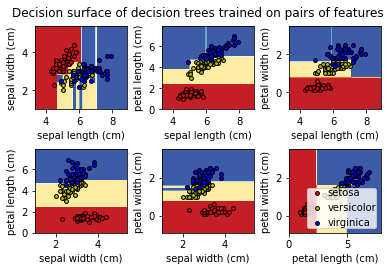

In [58]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

# 参数
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02

iris = load_iris()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    X = iris.data[:, pair]  # 仅取两个相应的特征
    y = iris.target

    clf = DecisionTreeClassifier().fit(X, y)  # 训练

    # 绘制决策边界
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # 绘制训练点
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            cmap=plt.cm.RdYlBu,
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

<div style="text-align: center;">图5-44  Iris数据集决策树的决策面</div>

显示在所有特征上训练的单棵决策树的结构。

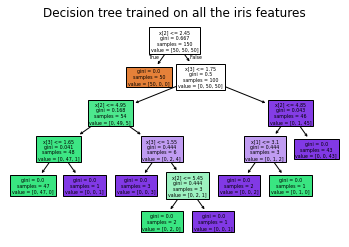

In [59]:
from sklearn.tree import plot_tree

plt.figure()
clf = DecisionTreeClassifier().fit(iris.data, iris.target)
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>在决策边界可视化中，每个子图展示了不同特征对的决策边界，这些边界将特征空间划分为不同区域，每个区域对应一个类别。例如，特征对 [0, 1] 的决策边界较为清晰，而特征对 [2, 3] 的决策边界则相对复杂。决策树结构图则展示了决策树的分裂过程，每个节点显示了分裂的特征和阈值，以及每个分支的样本分布。决策树的深度和复杂度取决于数据的特征和类别分布。
</p>

**例5-25：了解决策树的结构。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 这段代码旨在通过训练一个限制最大叶子节点数为3的决策树模型，深入分析决策树的结构和决策过程。它不仅展示了决策树的二叉树结构，包括每个节点的深度、是否为叶节点，还通过decision_path()和apply()方法，分别获取了样本经过的节点路径和到达的叶节点，进而输出了用于预测特定样本的规则，并分析了一组样本共享的决策路径，从而帮助我们理解特征与预测目标之间的关系以及模型的决策逻辑。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 加载数据集<br /> 
    2. 训练决策树模型<br /> 
    3. 分析决策树结构<br /> 
    4. 绘制决策树<br /> 
    5. 分析样本路径<br /> 
    6. 输出预测规则<br /> 
    7. 分析共享路径<br /> 
</details>


首先，使用iris数据集训练DecisionTreeClassifier。

In [16]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

clf = DecisionTreeClassifier(max_leaf_nodes=3, random_state=0)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=3, random_state=0)

为了检索树的结构，决策分类器设有一个名为tree_的属性，通过它可访问一些低级别属性，如节点总数node_count和树最大深度max_depth等。tree_属性还存储了整棵二叉树的结构，表示为多种数组。每个数组的第i个元素保存关于节点i的信息，节点0是树根。某些数组仅适用于叶节点或拆分节点。在这种情况下，其他类型的节点值是任意的。例如，数组feature和threshold仅适用于拆分节点。因此，这些数组中的叶节点值是任意的。

通过tree_属性可访问的数组如下。

（1）children_left[i]：节点i的左子节点的id，如果节点i为叶节点，则返回-1。
（2）children_right[i]：节点i的右子节点的id，如果节点i为叶节点，则返回-1。
（3）feature[i]：用于拆分节点i的特征。
（4）threshold[i]：节点i处的阈值。
（5）n_node_samples[i]：到达节点i的训练样本数。
（6）impurity[i]：节点i处的杂质不纯度。

使用上述数组可以遍历树的结构来计算各种属性。下面计算每个节点的深度，放入数组node_depth，并判断它是否是叶节点，若是，则放入数组is_leaves。

In [18]:
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # 从根节点id（0）及其深度（0）开始
while len(stack) > 0:
    node_id, depth = stack.pop()  # `pop`确保每个节点只访问一次
    node_depth[node_id] = depth

    # 如果一个节点的左、右子节点不相同，就得到一个拆分节点
    is_split_node = children_left[node_id] != children_right[node_id]
    # 如果是拆分节点，则将左、右子节点和深度附加到 `stack`上，以便循环遍历它
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print("The binary tree structure has {n} nodes and has the following tree structure:\n".format(n=n_nodes))
for i in range(n_nodes):
    if is_leaves[i]:
        print("{space}node={node} is a leaf node.".format(space=node_depth[i] * "\t", node=i))
    else:
        print(
            "{space}node={node} is a split node: go to node {left} if X[:, {feature}] <= {threshold} "
            "else to node {right}.".format(
                space=node_depth[i] * "\t",
                node=i,
                left=children_left[i],
                feature=feature[i],
                threshold=threshold[i],
                right=children_right[i],
            )
        )

The binary tree structure has 5 nodes and has the following tree structure:

node=0 is a split node: go to node 1 if X[:, 3] <= 0.800000011920929 else to node 2.
	node=1 is a leaf node.
	node=2 is a split node: go to node 3 if X[:, 2] <= 4.950000047683716 else to node 4.
		node=3 is a leaf node.
		node=4 is a leaf node.


可以将上面的输出与如图5-45所示的决策树的结构做比较，两者一致。

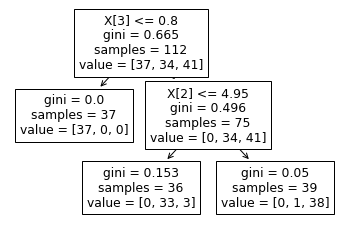

In [19]:
tree.plot_tree(clf)
plt.show()

<div style="text-align: center;">图5-45  决策树的结构</div  

我们还可以检索感兴趣的样本的决策路径。通过decision_path()方法返回一个指示符矩阵，该矩阵允许检索感兴趣的样本穿过的节点。在指示符矩阵中，在位置(i, j)处的非零元素指示样本i经过节点j。或者，对于一个样本i，指示符矩阵的第i行中的非零元素的位置指定样本经过的节点的id。

通过apply()方法可以获得感兴趣的样本所到达的叶节点的id。这将返回每个感兴趣的样本所到达的叶节点id的数组。通过使用叶节点ids和decision_path可以获得用于预测一个样本或一组样本的分裂条件。

首先，对一个样本进行测试。注意：node_index是一个稀疏矩阵。

In [21]:
node_indicator = clf.decision_path(X_test)
leaf_id = clf.apply(X_test)

sample_id = 0
# 获取“sample_id”经过的节点id，即行“sample_id”
node_index = node_indicator.indices[node_indicator.indptr[sample_id] : node_indicator.indptr[sample_id + 1]]

print("Rules used to predict sample {id}:\n".format(id=sample_id))
for node_id in node_index:
    # 如果是一个叶节点，则继续到下一个节点
    if leaf_id[sample_id] == node_id: 
        continue

    if X_test[sample_id, feature[node_id]] <= threshold[node_id]: # 检查样本0的分裂特征的值是否低于阈值
        threshold_sign = "<="
    else:
        threshold_sign = ">"

    print("decision node {node} : (X_test[{sample}, {feature}] = {value}) {inequality} {threshold})".format(
        node=node_id,
        sample=sample_id,
        feature=feature[node_id],
        value=X_test[sample_id, feature[node_id]],
        inequality=threshold_sign,
        threshold=threshold[node_id],
    ))

Rules used to predict sample 0:

decision node 0 : (X_test[0, 3] = 2.4) > 0.800000011920929)
decision node 2 : (X_test[0, 2] = 5.1) > 4.950000047683716)


对于一组样本，可以确定样本经过的公共节点。

In [22]:
sample_ids = [0, 1]
# boolean 数组，指示两个样本经过的节点
common_nodes = node_indicator.toarray()[sample_ids].sum(axis=0) == len(sample_ids)
# 使用数组中的位置获取节点id
common_node_id = np.arange(n_nodes)[common_nodes] 

print("The following samples {samples} share the node(s) {nodes} in the tree.".format(
        samples=sample_ids, nodes=common_node_id))
print("This is {prop}% of all nodes.".format(prop=100 * len(common_node_id) / n_nodes))

The following samples [0, 1] share the node(s) [0 2] in the tree.
This is 40.0% of all nodes.


><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>在通过分析决策树结构，我们深入了解了特征与预测目标之间的关系。代码展示了决策树的二叉树结构，包括每个节点的深度、是否为叶节点，以及节点的分裂规则。对于特定样本，输出了其经过的决策路径和预测规则，清晰地展示了样本如何通过决策树到达最终的预测结果。此外，还分析了一组样本共享的决策路径，揭示了这些样本在决策树中的共同特征和路径占比，为理解模型的决策过程提供了直观的依据。
</p>

#### <font color='blue' >5.6.3.2  回归</font>

通过使用DecisionTreeRegressor类，决策树也可用于回归问题。与分类设置一样，拟合方法将采用数组X和y作为参数，只是在这种情况下，y应具有浮点值而不是整数值。

In [23]:
from sklearn import tree
X = [[0, 0], [2, 2]]
y = [0.5, 2.5]
clf = tree.DecisionTreeRegressor()
clf = clf.fit(X, y)
clf.predict([[1, 1]])

array([0.5])

例5-26给出了一个使用决策树实现一维回归的示例，如图5-46。构建具有附加噪声的可观测的正弦曲线，决策树学习局部线性回归用于近似正弦曲线。可以看到，如果树的最大深度（由max_depth参数控制）设置得太大，则决策树学习训练数据的太多细节，并从噪声中学习，即它们过拟合了。

**例5-26：决策树回归。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 这段代码展示了如何使用 scikit-learn 的 DecisionTreeRegressor 来拟合一个回归模型，并通过调整决策树的最大深度来观察模型的拟合效果。代码生成了一个简单的正弦函数数据集，并在数据中加入了一些噪声，然后使用两个不同深度的决策树回归模型进行拟合，并可视化了拟合结果。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 生成数据集<br /> 
    2. 训练回归模型<br /> 
    3. 预测<br /> 
    4. 可视化结果<br /> 
</details>

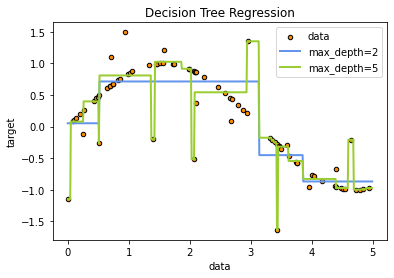

In [24]:
# 导入必要的模块和库
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.RandomState(1)  # 创建一个随机数据集
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

regr_1 = DecisionTreeRegressor(max_depth=2)  # 拟合回归模型
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]  # 预测
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

# 绘制结果
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [ ]:
<div style="text-align: center;">图5-46 决策树回归</div>

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>通过使用不同最大深度的决策树回归模型对带有噪声的正弦函数数据进行拟合，结果表明，深度较浅的决策树（如max_depth=2）能够提供较为平滑的拟合曲线，但可能无法捕捉到数据中的所有细节，存在欠拟合的风险；而深度较深的决策树（如max_depth=5）能够更好地拟合数据中的复杂模式，包括噪声点，但可能会导致过拟合。可视化结果显示，随着决策树深度的增加，模型对数据的拟合能力增强，但同时也增加了对噪声的敏感性。这表明在实际应用中，需要根据数据的复杂度和噪声水平合理选择决策树的深度，以平衡模型的拟合能力和泛化能力。
</p>

#### <font color='blue' >5.6.3.3  多输出问题</font>

多输出问题是一个<font color='red'>有监督学习问题</font>，且有多个输出要预测，即Y是一个形状为(n_samples,n_outputs)的二维数组。

当多输出之间没有相关性时，解决这类问题的一个简单方法就是建立n个独立的模型，即每个输出对应一个模型，使用这些模型独立预测个输出中的每个。由于与同一输入相关的多输出之间很可能是相关的，一个更好的方法是建立一个能够同时预测所有n个输出的单个模型。首先，构建了一个估计器，它需要较少的训练时间；其次，估计器的泛化精度通常可以增加。关于决策树，这种策略可以很容易地用于支持多输出问题，但需要进行以下更改：①将n个输出存储在叶节点中，而不仅是1个输出；②使用分割标准计算n个输出的平均减小量。

Scikit-learn中通过在DecisionTreeClassifier和DecisionTreeRegressor中均实现该策略，为多输出问题提供支持。如果决策树适用于形状为(n_samples,n_outputs)的输出阵列，则所得估计器将：①在使用predict()方法时，输出n_outputs个预测值；②在使用predict_proba()方法时，输出具有n_Output个类别概率的数组列表。

例5-27演示了如何使用多输出树进行回归，如图5-47所示。输入是单个实数，输出是输入的正弦和余弦。构建一个圆的含噪声的输入和输出观测值，决策树同时预测正/余弦，它学习近似圆的局部线性回归。

**例5-27：多输出决策树回归。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 这段代码展示了如何使用 scikit-learn 的 DecisionTreeRegressor 来拟合一个多输出回归模型。代码生成了一个包含两个目标变量（正弦和余弦函数）的随机数据集，并在数据中加入了一些噪声。然后，使用三个不同深度的决策树回归模型（最大深度分别为 2、5 和 8）对数据进行拟合，并可视化了拟合结果。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 生成数据集<br /> 
    2. 训练回归模型<br /> 
    3. 预测<br /> 
    4. 可视化结果<br /> 
</details>

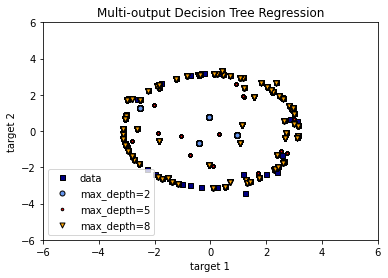

In [25]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.tree import DecisionTreeRegressor

rng = np.random.RandomState(1)  # 构建一个随机数据集
X = np.sort(200 * rng.rand(100, 1) - 100, axis=0)
y = np.array([np.pi * np.sin(X).ravel(), np.pi * np.cos(X).ravel()]).T
y[::5, :] += 0.5 - rng.rand(20, 2)

regr_1 = DecisionTreeRegressor(max_depth=2)  # 拟合回归模型
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_3 = DecisionTreeRegressor(max_depth=8)
regr_1.fit(X, y)
regr_2.fit(X, y)
regr_3.fit(X, y)

X_test = np.arange(-100.0, 100.0, 0.01)[:, np.newaxis]  # 预测
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
y_3 = regr_3.predict(X_test)

plt.figure()  # 绘制结果
s = 25
plt.scatter(y[:, 0], y[:, 1], marker=',', c="navy", s=s, edgecolor="black", label="data")
plt.scatter(y_1[:, 0], y_1[:, 1], c="cornflowerblue", s=s, edgecolor="black", label="max_depth=2")
plt.scatter(y_2[:, 0], y_2[:, 1], marker='.', c="red", s=s, edgecolor="black", label="max_depth=5")
plt.scatter(y_3[:, 0], y_3[:, 1], marker='v', c="orange", s=s, edgecolor="black", label="max_depth=8")
plt.xlim([-6, 6])
plt.ylim([-6, 6])
plt.xlabel("target 1")
plt.ylabel("target 2")
plt.title("Multi-output Decision Tree Regression")
plt.legend(loc="best")
plt.show()

<div style="text-align: center;">图5-47  多输出决策树回归</div>

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>通过使用不同最大深度的决策树回归模型对包含噪声的多输出数据集进行拟合，结果表明，随着决策树深度的增加，模型对数据的拟合能力显著增强。深度较浅的模型（如max_depth=2）拟合效果较为平滑，但可能无法捕捉到数据中的复杂模式，存在欠拟合的风险；而深度较深的模型（如max_depth=8）能够更好地拟合数据中的细节，但可能会对噪声数据过度拟合，导致过拟合。这表明在实际应用中，需要根据数据的复杂度和噪声水平合理选择决策树的深度，以平衡模型的拟合能力和泛化能力。
</p>

#### <font color='blue' >5.6.3.4  缺失值支持</font>

在DecisionTreeClassifier和DecisionTreeRegistor类的构造函数中，可以通过splitter参数选择每个节点的拆分策略，有两种策略$\{\mathrm{"best","random"}\}$，默认值为$\mathrm{^{\prime\prime}best^{\prime\prime}}$。同样，还有用于度量节点拆分质量的参数criterion。在设置splitter=$\mathrm{^{\prime\prime}best^{\prime\prime}}$且节点拆分质量参数criterion或者在分类问题中设为$\mathrm{'gini'}$、$^{\prime}entropy^{\prime}$或$\mathrm{log~1oss'}$，或者在回归问题中设为$\text{'squared error'}$、$^{\prime}friedman mse^{\prime}$或$\mathrm{'poisson'}$时，DecisionTreeClassifier和DecisionTreeRegistor均内置了对缺失值的支持。对于非缺失数据的每个潜在阈值，拆分器将评估拆分，所有缺失值都将转到左节点或右节点。

预测时，在默认情况下，具有缺失值的样本会按照在训练期间发现的拆分中使用的类别进行分类。

In [53]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

X = np.array([0, 1, 6, np.nan]).reshape(-1, 1)
y = [0, 0, 1, 1]

tree = DecisionTreeClassifier(random_state=0).fit(X, y)
print(tree.predict(X))

[0 0 1 1]


如果两个节点的评估标准相同，则拆分器检查拆分，其中所有缺失值都将转到一个子项中，而非缺失值将转到另一个子项中。

In [56]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

X = np.array([np.nan, -1, np.nan, 1]).reshape(-1, 1)
y = [0, 0, 1, 1]

tree = DecisionTreeClassifier(random_state=0).fit(X, y)

X_test = np.array([np.nan]).reshape(-1, 1)
print(tree.predict(X_test))

[1]


如果在给定特征的训练过程中没有发现缺失值，那么在预测过程中，缺失值将映射到具有最多样本的子项中。

In [57]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

X = np.array([0, 1, 2, 3]).reshape(-1, 1)
y = [0, 1, 1, 1]

tree = DecisionTreeClassifier(random_state=0).fit(X, y)

X_test = np.array([np.nan]).reshape(-1, 1)
print(tree.predict(X_test))

[1]


#### <font color='blue' >5.6.3.5  最小成本复杂性剪枝</font>

最小成本复杂性剪枝是一种用于修剪树以避免过拟合的算法。此算法由一个被称为复杂性的参数$\alpha\geqslant0$进行参数化。复杂性参数用于定义树$T$的成本复杂性指标$R_{\alpha}\left(T\right)=R(T)+\alpha\left|\tilde{T}\right|$,其中，$\left|\tilde{T}\right|$是$T$ 中的叶节点数，$R(T)$ 或是叶节点的总错分率或Scikit-learn 中使用的叶节点的加权杂质。最小成本复杂性剪枝找到$T$ 的子树以最大限度地减小$R_\alpha\left(T\right)$。

单个节点的成本复杂性指标为$R_\alpha\left(T\right)=R\left(T\right)+\alpha$。分支$T_t$ 定义为以节点$t$ 为根的子树。通常节点的杂质大于其叶节点的杂质之和，即$R(T_t)<R(t)$。然而，一个节点$t$ 及其分支$T_t$ 的成本复杂性指标是可以相等的，这取决于$\alpha$。定义一个节点的有效$\alpha$值，使得$R_{\alpha}\left(T_{t}\right)=R_{\alpha}\left(t\right)$或$\alpha_{\mathrm{eff}}\left(t\right)=\frac{R(t)-R(T_{\iota})}{\left|T\right|-1}$。具有最小$\alpha_\mathrm{eff}$值的非叶节点是最薄弱的环节，将被剪枝。当树的最小$\alpha_\mathrm{eff}$ 值大于预先设定的 ccp\_alpha 参数时，剪枝过程停止。


例 5-28 展示了最小成本复杂性剪枝算法的执行效果及其各参数的影响。

**例 5-28: 使用最小成本复杂性剪枝算法的后剪枝决策树。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 这段代码展示了如何使用 scikit-learn 的 DecisionTreeClassifier 来训练决策树分类器，并通过成本复杂性剪枝（Cost-Complexity Pruning）来优化模型的复杂度。代码使用了乳腺癌数据集（load_breast_cancer），并分析了不同剪枝参数（ccp_alpha）对模型复杂度和性能的影响。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 加载数据集<br /> 
    2. 成本复杂性剪枝路径<br /> 
    3. 训练不同剪枝参数的模型<br /> 
    4. 评估模型性能<br /> 
</details>

DecisionTreeClassifier 提供了 min samples leaf 和 max depth 等参数，以防止树过拟合。成本复杂性剪枝为控制树的大小提供了另一种选择。在 DecisionTreeClassifier 中，此剪枝技术由成本复杂性参数 ccp alpha 进行参数化。ccp alpha 的值越大，修剪的节点数越多。此处只展示 ccp alpha 对正则化树的影响，以及如何根据验证分数选择一个 ccp alpha 值。

首先导入DecisionTreeClassifier

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

最小成本复杂性剪枝算法递归地找到具有最弱环节的节点。最弱环节以一个有效的$\alpha$ 值为特征，首先修剪具有最小有效$\alpha$值的节点。要判断 ccp alpha 的值是否合适，Scikit-learn 提供了 DecisionTreeClassifier.cost\_complexity\_pruning\_path()方法，它在剪枝过程的每个步骤返回有效的$\alpha$值和相应的总叶节点杂质。随着$\alpha$值的增大，更多的子树被修剪，这增加了树叶节点的总杂质，如图 5-48 所示。

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

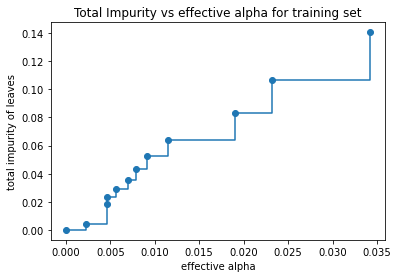

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

clf = DecisionTreeClassifier(random_state=0)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

图5-48  剪枝后树的有效ccp_alpha值和树的叶节点的总杂质

接下来，使用有效的α值来训练决策树。ccp_alphas中的最后一个值是剪枝整个树的α值，使树clfs[-1]只剩下一个节点。

In [4]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.3272984419327777


对于本例的其余部分，删除clfs和ccp_alphas中的最后一个元素，因为它是一棵只有一个节点的平凡树。在此展示节点数量和树的深度随着α的增大而减小，如下图所示。

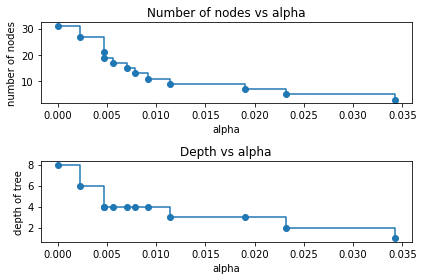

In [5]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

训练集和测试集的准确率与α值。当设置ccp_alpha=0并保持DecisionTreeClassifier类的其他默认参数时，树将过拟合，导致100%的训练准确率和88%的测试准确率。随着α的增大，修剪了更多的子树，从而创建了一棵更通用的决策树。在本例中，设置ccp_alpha=0.015可最大限度地提高测试精度，如下图所示。

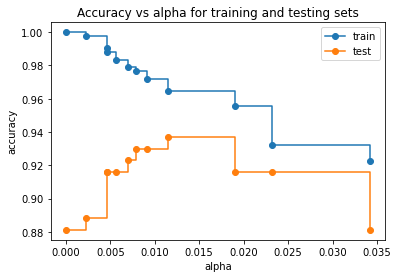

In [6]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>通过分析不同剪枝参数（ccp_alpha）对决策树分类器的影响，结果表明，随着ccp_alpha的增加，决策树的复杂度（节点数和树深度）逐渐降低，叶节点的总不纯度也随之减少，这表明剪枝有效地简化了模型。在训练集上，模型的准确率随着ccp_alpha的增加而降低，说明剪枝减少了模型对训练数据的拟合能力；而在测试集上，准确率在某个ccp_alpha值处达到峰值，表明适当的剪枝可以提高模型的泛化能力，但过度剪枝会导致模型性能下降。因此，通过选择合适的ccp_alpha值，可以在模型复杂度和泛化能力之间取得平衡。
</p>

#### <font color='blue' >5.6.3.6  实用技巧</font>

决策树作为一个有效的<font color='red'>分类器或预测器</font>，为了发挥其最大效能，还需要一些实用技巧。

- （1）决策树通常对具有大量特征的数据过拟合。样本数量与特征数量的正确比率是很重要的，因为在高维空间中，样本较少的树很可能会过拟合。

- （2）通过提前执行降维（PCA、ICA或特征选择）操作可以使树有更好的机会找到具有判别力的特征。

- （3）了解决策树的结构将有助于深入了解决策树如何进行预测，这对于理解数据中的重要特征非常重要。

- （4）通过使用export()函数，在训练时将树可视化。首先，通过设置max_depth=3为初始的树深度来了解树如何拟合数据；然后增加深度。

- （5）树每增长一个额外层，填充树所需的样本数量都会翻倍。使用max_depth来控制树的大小，以防止过拟合。

- （6）通过参数min_samples_split或min_samples_leaf控制分裂将被考虑，确保多个样本用于训练树中的每个决策。如果该值是一个非常小的数，则通常意味着树将过拟合；而一个较大的数将阻止树学习数据。试着将min_samples_leaf=5作为初始值。如果样本量变化很大，则可以使用这两个参数的百分比来描述。虽然min_samples_split可以创建任意小的叶节点，但min_samples_leaf保证每个叶节点都有最小的样本量，避免了回归问题中的低方差、过拟合叶节点。对于类别较少的分类，min_samples_leaf=1通常是最优选择。请注意，如果规定具有m个加权样本的节点仍然被视为正好具有m个样本，min_samples_split直接考虑样本，并且独立于sample_weight。如果拆分时需要考虑样本权重，则请考虑min_weight_fraction_leaf或min_impurity_drease的取值。

- （7）在训练前平衡数据集，以防止树偏向于占主导数量的类别。类平衡可以通过从每个类中采样相等数量的样本来完成，或者优先地通过将每个类别的样本权重（sample_weight）之和归一化来完成。还要注意的是，与不知道样本权重的标准（如min_samples_leaf）相比，基于权重的预修剪标准，如min_weight_fraction_leaf对样本数量占优的类别的偏见较小。

- （8）如果对样本进行加权，则使用基于权重的预修剪标准（如min_weight_fraction_leaf）更容易优化树的结构，该标准确保叶节点至少包含样本权重总和的一小部分。

- （9）所有决策树内部都使用np.float32数组。

- （10）如果输入矩阵非常稀疏，则建议在调用fit()之前将其转换为稀疏 csc_matrix，在调用predict()之前转换成稀疏csr_matrix。当特征在大多数样本中具有零值时，与密集矩阵相比，稀疏矩阵输入的训练时间可以快几个数量级。

### <font color='blue' >5.6.4  算法小结</font>

通过本节的学习，读者可以了解信息论中几个关键的概念，理解决策树生成算法、决策树评估和通过剪枝消除过拟合等方法，并将这些理论和方法体现在决策树实践中。<font color='red'>决策树方法的主要优点有</font>：①易于理解和解释，决策树可以被可视化；②应用决策树的时间成本是用于训练决策树的数据点数量的对数；③能够处理数值和分类数据；④能够处理多输出问题；⑤采用了白盒模型，如果给定的情况在模型中是可观察的，那么对条件的解释很容易用布尔逻辑来解释，相比之下，在黑盒模型（如人工神经网络）中，结果可能较难解释；⑥可以使用统计测试验证模型。这样就可以考虑模型的可靠性。

<font color='red'>决策树方法的缺点及其改进如下：</font>

- （1）可以创建较复杂的树，这些树不能很好地概括数据，而过多的学习了噪声的信息，这被称为过拟合。修剪、设置叶节点所需的最小样本数或设置树的最大深度等机制对于避免此问题是必要的。

- （2）决策树可能不稳定，因为数据的微小变化可能导致生成完全不同的树。通过后面的集成学习训练多棵树来缓解这个问题。

- （3）决策树的预测既不是平滑的，又不是连续的，而是与如图5-46所示的分段常数近似。因此，它们不擅长外推。

- （4）学习最优决策树的问题都是NP完全的。因此，实际的决策树学习算法是基于启发式的算法，如贪心算法，其在每个节点处做出局部最优决策。这样的算法不能保证返回全局最优的决策树。该问题可通过在集成学习器中训练多棵树来缓解，其中特征和样本是通过随机采样替换的。

- （5）如果某些类的样本数量占样本总量的大多数，则决策树学习会创建有偏的树。因此，建议在决策树拟合之前先平衡数据集。

## <font color='blue' >5.7　聚类</font>

聚类是一种无监督学习任务（数据没有标注），该算法基于数据的内部结构寻求观察样本的自然族群（簇）。该算法案例包括细分客户、新闻聚类、文章推荐等。

### <font color='blue' >5.7.1  K均值聚类</font>

<font color='red'>K均值聚类(记为KMeans)</font>是一种通用目的的算法，聚类的度量基于样本点间的几何距离。簇是围绕在聚类中心的族群，而簇呈现出类球状并具有相似的大小。聚类算法不仅十分简单，还足够灵活以在面对大多数问题时都能给出合理的结果。在本节中，簇是具有近似性质的样本族群，是一种数据存在的形态；而聚类是一个过程，有时也表示该过程的结果。因此，簇和聚类这两个概念不再加以细分，读者可根据上下文理解。

根据最大限度地减少聚类内平方和准则，KMeans算法尝试将样本分为组方差大致相等的样本簇实现数据聚类。此类算法需要指定簇的数量，能够较好地扩展到具有大样本量的问题，并已在许多不同领域得到广泛应用。

KMeans 算法将一个具有$N$个样本的集合$X$划分为$K$个不相交簇$C$。每个簇使用簇内样本的平均值$\mu_j$来描述，其通常被称为聚类的质心。请注意，质心通常不是来自$X$的样本， 尽管它们在同一个空间里。

KMeans算法旨在选择最小化簇内平方和的质心，如式（5-36）所示。

<div style="text-align: center;">$\sum_{i=0}^{n}\min_{\mu_{i}\in\mathbb{C}}(x_{i}-\mu_{j})^{2}$

式（5-36）中的准则可被认为是衡量簇内一致性程度的一种指标。它具有以下缺点。

（1）该准则假设簇是凸的和各向同性的，但实际数据情况并非总是如此。它对细长的簇或形状不规则的流形效果不佳。

（2）该准则不是一个规则化的指标，我们只知道其值越小越好，零值情况是最优的。但在高维空间中，欧几里得距离通常会变得膨胀（这就是所谓的“维度诅咒”）。在K均值聚类之前，运行诸如主成分分析之类的降维算法可以缓解这个问题并加快计算。

KMeans算法通常被称为Lloyd算法，主要有3个步骤。

第一步：选择初始化质心，基本方法是从数据集X中选择k个样本。

第二步：将每个样本分配到离其最近的质心所属的簇。

第三步：获取分配给每个质心的所有样本并求平均值为新质心。重复最后两步，计算新、旧质心之间的差，直到该值小于一个预先给定的阈值，即质心没有明显移动。

只要有足够的时间，KMeans算法就总能收敛，但可能收敛到局部最小值。这在很大程度上取决于质心的初始化。因此，我们通常多次执行算法，每次质心的初始化不同。在Scikit-learn中，设置参数init="k-means++"以实现k-means++初始化方案，通常会将质心初始化为彼此相距较远，可能会产生比随机初始化更好的结果。K-means++也可以独立调用，为其他聚类算法选择种子，有关详细信息和示例用法请参阅sklearn.cluster.keans_plusplus。

KMeans算法支持样本权重，样本权重可由参数sample_weight设定。这允许在计算簇中心和准则值时为一些样本分配更多的权重。例如，将权重2分配给某样本相当于将该样本的一个副本添加到数据集X中。KMeans算法还支持并行处理小块数据（256个样本），这将节省内存的占用。

**例5-29：KMeans算法假设的展示。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 本例展示KMeans算法产生的非直觉的和可能不想要的聚类情况。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 数据集生成。<br /> 
    2. 拟合模型并绘制结果。<br /> 
    3. 可能的解决方案。<br /> 
</details>

第一步，数据集生成。

使用函数make_blobs()生成各向同性（球形）、服从高斯分布的数据集。为了获得各向异性（椭圆）、服从高斯分布的数据集，必须定义一个线性transformation。

In [3]:
import numpy as np
from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))  # 不平衡
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

生成数据的可视化，如图5-51所示。

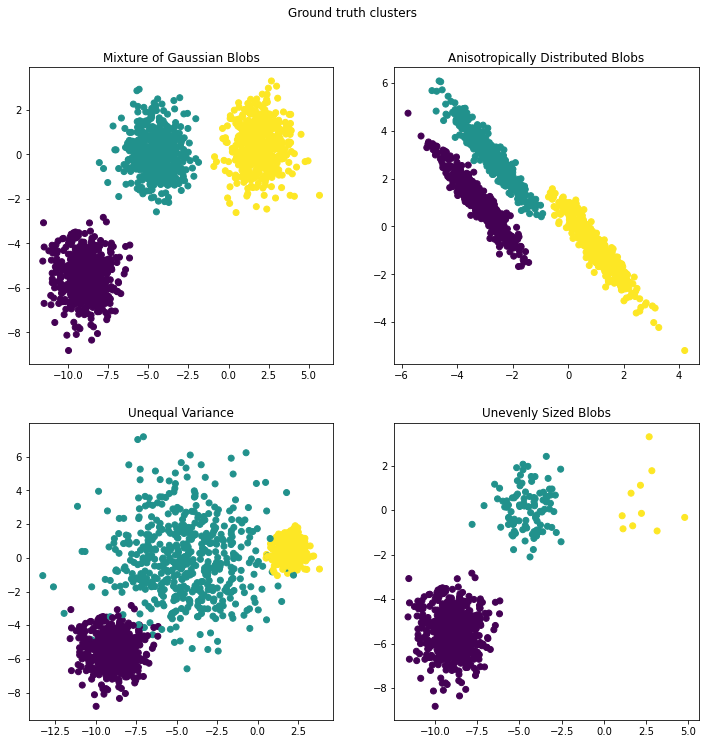

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")
axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")
axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

<div style="text-align: center;">图5-51  不同情况下的样本数据

第二步，拟合模型并绘制结果。

如图5-51所示，第一步生成的数据现被用于展示KMean算法在不同数据集情况下的执行效果。

（1）非最优簇数量：必须根据对数据的标准和预期目标的了解来决定适当的簇数量。

（2）各向异性分布数据集：KMeans算法包括最小化样本到其所分配簇质心的欧几里得距离。因此，KMeans算法更适用于各向同性和正态分布的聚类（球形高斯）。

（3）不等方差：K均值相当于对具有相同方差但可能具有不同均值的K个高斯分布的“混合物”进行最大似然估计。

（4）类别样本数量不平衡的数据集：没有相关理论表明KMeans算法需要相似的聚类大小才能表现良好，但最小化欧几里得距离确实意味着问题的样本集越稀疏和高维，就越需要使用不同的质心种子运行算法。

In [1]:
import sklearn
print(sklearn.__version__)  # 若输出非1.4+则说明版本未更新[1](@ref)

1.6.1


C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

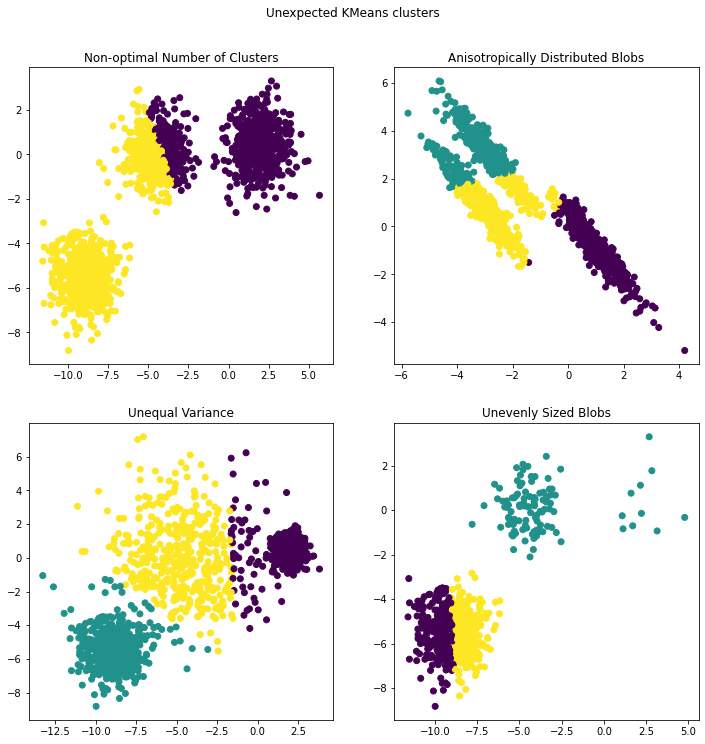

In [5]:
from sklearn.cluster import KMeans

common_params = {"n_init": "auto", "random_state": random_state}
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

y_pred = KMeans(n_clusters=2, **common_params).fit_predict(X)
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_pred)
axs[0, 0].set_title("Non-optimal Number of Clusters")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_aniso)
axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_varied)
axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
axs[1, 0].set_title("Unequal Variance")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_filtered)
axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Unexpected KMeans clusters").set_y(0.95)
plt.show()

<div style="text-align: center;">图5-52  样本数据在不同配置情况下的KMeans算法的运行结果

上述代码片段描述了在簇数量不对，各向异性分布、方差不等和簇大小不均匀情况下KMeans算法的运行结果，如图5-52所示。

第三步，可能的解决方案。

簇数量设置不同的效果如图5-53所示，其中设置n_clusters=3。图5-52的左上子图是簇数量设置为2的结果。两者比较，前者更准确。

C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


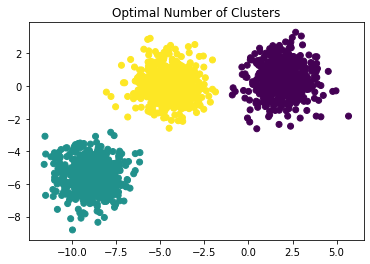

In [6]:
y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Optimal Number of Clusters")
plt.show()

<div style="text-align: center;">图5-53  簇数量设置不同的结果

为了处理不同类别样本数量不均匀的簇，可以增加随机初始化的次数。在这种情况下，设置n_init=10以避免找到次优局部最小值，如图5-54所示。

C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


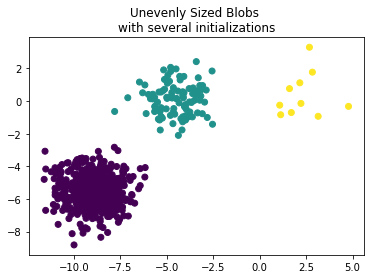

In [7]:
y_pred = KMeans(n_clusters=3, n_init=10, random_state=random_state).fit_predict(X_filtered)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("Unevenly Sized Blobs \nwith several initializations")
plt.show()

<div style="text-align: center;">图5-54  设置n_init=10以避免找到次优局部最小值

由于各向异性和不等方差是K Means算法的实际限制，因此建议使用GaussianMixture，它也假设了高斯聚类，但不对样本方差施加任何约束，如图5-55所示。请注意，此时仍然需要找到数据集的正确类别数量。

C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


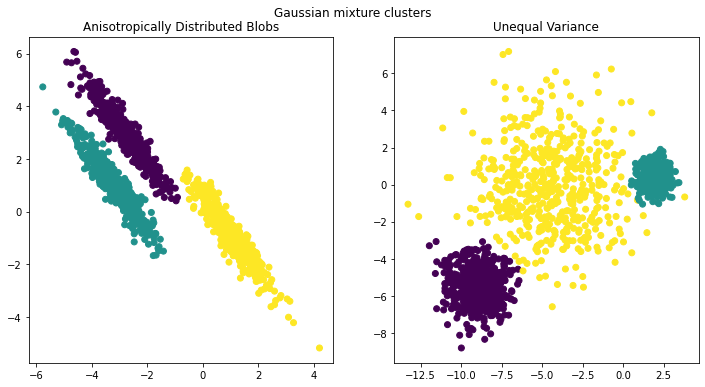

In [8]:
from sklearn.mixture import GaussianMixture

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

y_pred = GaussianMixture(n_components=3).fit_predict(X_aniso)
ax1.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
ax1.set_title("Anisotropically Distributed Blobs")

y_pred = GaussianMixture(n_components=3).fit_predict(X_varied)
ax2.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
ax2.set_title("Unequal Variance")

plt.suptitle("Gaussian mixture clusters").set_y(0.95)
plt.show()

<div style="text-align: center;">图5-55  GaussianMixture的应用

在高维空间中，欧几里得距离往往会膨胀。在KMeans聚类之前运行降维算法可以缓解这个问题并加快计算速度。

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>由例5-29可知，在已知聚类是各向同性、具有相似方差且不太稀疏的情况下，KMeans算法是非常有效的，并且是可用的最快的聚类算法之一。如果需要多次执行该算法以避免收敛到局部最小值，那么这种优势可能会丧失。
</p>

在例5-30中，在运行时间和结果质量方面比较了KMeans算法的各种初始化策略。

**例5-30：手写数字数据集上的KMeans聚类演示。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 本例展示KMeans算法产生的非直觉的和可能不想要的聚类情况。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 加载数据集。<br /> 
    2. 定义评估基准。<br /> 
    3. 运行基准程序。<br /> 
    4. 在PCA降维后的数据上训练结果的可视化。<br /> 
</details>

由于本例中数据的真实值是已知的，因此这里还应用了不同的聚类质量指标来判断聚类方法的拟合优度。

本例中用于评估聚类质量的指标如表5-3所示。

<div style="text-align: center;">表5-3  聚类质量指标

| 简写 | 名称 |
|------|-----|
| homo | homogeneity score |
| compl | completeness score |
| v-meas | V-measure |
| ARI | adjusted Rand index |
| AMI | adjusted mutual information |
| silhouette | silhouette coefficient |

第一步，加载数据集。

需要加载的手写数字数据集包含从0到9的手写数字图像。我们希望对图像进行分组，使得每组图像上的手写数字相同。

In [14]:
import numpy as np
from sklearn.datasets import load_digits

data, labels = load_digits(return_X_y=True)
(n_samples, n_features), n_digits = data.shape, np.unique(labels).size

print(f"# digits: {n_digits}; # samples: {n_samples}; # features {n_features}")

# digits: 10; # samples: 1797; # features 64


第二步，定义评估基准。

首先确定要使用的评估基准。在评估期，我们打算比较KMean算法的不同初始化方法，使用的基准有：①创建一个管道，其中使用了StandardScaler缩放数据；②训练并计时管道；③通过不同指标度量获得的聚类性能。

In [13]:
from time import time

from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def bench_k_means(kmeans, name, data, labels):
    """评估 KMeans 的初始化方法的基准

    kmeans : KMeans 已初始化的 `~sklearn.cluster.KMeans` 实例
    name : str，策略名称。它将用于在表格中显示结果
    data : 形状为 (n_samples, n_features) 的数组，是要聚类的数据
    labels : 形状为 (n_samples,) 的数组，用于计算聚类度量的标签，这需要一些监督
    """
    t0 = time()
    estimator = make_pipeline(StandardScaler(), kmeans).fit(data)
    fit_time = time() - t0
    results = [name, fit_time, estimator[-1].inertia_]

    # 定义只需真实标签和估计器标签的指标
    clustering_metrics = [
        metrics.homogeneity_score,
        metrics.completeness_score,
        metrics.v_measure_score,
        metrics.adjusted_rand_score,
        metrics.adjusted_mutual_info_score,
    ]
    results += [m(labels, estimator[-1].labels_) for m in clustering_metrics]

    # silhouette 得分，需要完整的数据集
    results += [metrics.silhouette_score(data, estimator[-1].labels_, metric="euclidean", sample_size=300)]

    # 显示结果
    formatter_result = ("{:9s}\t{:.3f}s\t{:.0f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}")
    print(formatter_result.format(*results))

第三步，运行基准程序。

这里比较三种方法。

- （1）使用k-means++进行初始化。这种方法是随机的，这里将运行初始化4次。

- （2）随机初始化。这种方法也是随机的，这里将运行初始化4次。

- （3）基于PCA投影的初始化。实际上，这里使用pca.components_来初始化KMean算法。这种方法是确定的，一次初始化就足够。

In [24]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print(82 * "_")
print("init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette")

kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="k-means++", data=data, labels=labels)

kmeans = KMeans(init="random", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="random", data=data, labels=labels)

pca = PCA(n_components=n_digits).fit(data)
kmeans = KMeans(init=pca.components_, n_clusters=n_digits, n_init=1)
bench_k_means(kmeans=kmeans, name="PCA-based", data=data, labels=labels)

print(82 * "_")

__________________________________________________________________________________
init		time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
k-means++	0.073s	69662	0.680	0.719	0.699	0.570	0.695	0.172
random   	0.048s	69707	0.675	0.716	0.694	0.560	0.691	0.187
PCA-based	0.016s	74152	0.653	0.683	0.668	0.539	0.664	0.141
__________________________________________________________________________________


第四步，在PCA降维后的数据上训练结果的可视化。

PCA将数据从原始64维空间投影到较低维空间中。下面使用PCA投影将数据到二维空间中，并在这个新空间中绘制数据和聚类，如图5-56所示。

In [25]:
import matplotlib.pyplot as plt

reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4)
kmeans.fit(reduced_data)

KMeans(n_clusters=10, n_init=4)

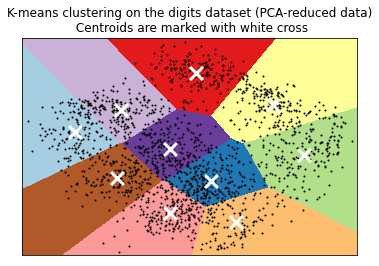

In [26]:
h = 0.02  # 网格的步长。降低以提高VQ的质量

# 绘制决策边界。为此，将为每个赋值一个颜色
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 获取网格中每个点的标签。使用上次训练的模型
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# 将结果放入彩色图中
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# 将质心绘制为白色X
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=169, linewidths=3, color="w", zorder=10)
plt.title("K-means clustering on the digits dataset (PCA-reduced data)\n Centroids are marked with white cross")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()

<div style="text-align: center;">图5-56  手写数字数据集上的K-Means聚类展示

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>由上述若干示例可知，KMeans算法是最流行的聚类算法之一，因为该算法足够快速、简单，并且如果预处理数据和特征工程十分有效，那么该聚类算法将拥有令人惊叹的灵活性。但该算法需要指定簇的数量，而K值的选择通常都不是那么容易确定的。另外，如果训练数据中的真实簇并不是类球状的，那么KMeans算法会得出一些效果比较差的簇。
</p>

### <font color='blue' >5.7.2  小批量KMeans</font>

MiniBatchKMeans是KMeans算法的一个变体，它使用小批量样本来减少计算时间，但依然试图优化相同的目标函数。小批量是输入数据的子集，在每个训练迭代中随机采样。这些小批量大大减小了收敛到局部解所需的计算量。与其他减少收敛时间的算法相比，MiniBatchKMeans算法产生的结果通常只比标准算法略差。

类似于最初的KMeans，MiniBatchKMeans算法也是在两个主要步骤间迭代。第一步，首先从数据集中随机抽取K个样本，形成一个小批量；然后，将它们指定给最近的质心。第二步，针对于小批量中的每个样本，通过获取样本和所有先前分配至该质心的样本的流式平均值更新质心。迭代执行这两步，直到收敛或达到预定的迭代次数。

MiniBatchKMeans比KMeans收敛得更快，但其结果的质量会降低。在实践中，这种质量差异可能非常小。

**例5-31：KMeans和MiniBatchKMeans聚类算法的比较。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 本例展示KMeans和MiniBatchKMeans聚类算法的比较。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 生成数据。<br /> 
    2. KMeans聚类。<br /> 
    3. MiniBatchKMeans聚类。<br /> 
    4. 在聚类间建立奇偶校验。<br /> 
    5. 绘制结果。<br /> 
</details>

通过比较MiniBatchKMeans和KMeans算法的性能可知，MiniBatchKMean的收敛速度更快，但它给出的结果略有不同。

下面使用KMeans和MiniBatchKMeans算法对同一组数据进行聚类，并绘制结果，绘制两种算法标记的不同点。

第一步，生成数据。

首先生成要聚类的数据块。

In [9]:
import numpy as np
from sklearn.datasets import make_blobs

np.random.seed(0)

batch_size = 45
centers = [[1, 1], [-1, -1], [1, -1]]
n_clusters = len(centers)
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.7)

第二步，KMeans聚类。

In [10]:
import time
from sklearn.cluster import KMeans

k_means = KMeans(init="k-means++", n_clusters=3, n_init=10)
t0 = time.time()
k_means.fit(X)
t_batch = time.time() - t0

第三步，MiniBatchKMeans聚类。

In [11]:
from sklearn.cluster import MiniBatchKMeans

mbk = MiniBatchKMeans(
    init="k-means++",
    n_clusters=3,
    batch_size=batch_size,
    n_init=10,
    max_no_improvement=10,
    verbose=0,
)
t0 = time.time()
mbk.fit(X)
t_mini_batch = time.time() - t0

C:\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


第四步，在聚类间建立奇偶校验。

我们希望MiniBatchKMeans和KMeans算法中的同一聚类的样本点具有相同的颜色。下面将最接近的聚类中心配对。

In [12]:
from sklearn.metrics.pairwise import pairwise_distances_argmin

k_means_cluster_centers = k_means.cluster_centers_
order = pairwise_distances_argmin(k_means.cluster_centers_, mbk.cluster_centers_)
mbk_means_cluster_centers = mbk.cluster_centers_[order]

k_means_labels = pairwise_distances_argmin(X, k_means_cluster_centers)
mbk_means_labels = pairwise_distances_argmin(X, mbk_means_cluster_centers)

第五步，绘制结果，如图5-57所示。

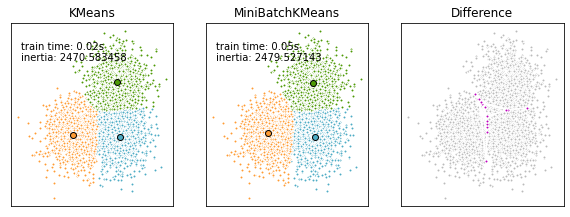

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 3))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#4EACC5", "#FF9C34", "#4E9A06"]

# KMeans
ax = fig.add_subplot(1, 3, 1)
for k, col in zip(range(n_clusters), colors):
    my_members = k_means_labels == k
    cluster_center = k_means_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], "w", markerfacecolor=col, marker=".")
    ax.plot(cluster_center[0], cluster_center[1], "o", markerfacecolor=col, markeredgecolor="k", markersize=6)
ax.set_title("KMeans")
ax.set_xticks(())
ax.set_yticks(())
plt.text(-3.5, 1.8, "train time: %.2fs\ninertia: %f" % (t_batch, k_means.inertia_))

# MiniBatchKMeans
ax = fig.add_subplot(1, 3, 2)
for k, col in zip(range(n_clusters), colors):
    my_members = mbk_means_labels == k
    cluster_center = mbk_means_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], "w", markerfacecolor=col, marker=".")
    ax.plot(cluster_center[0], cluster_center[1], "o", markerfacecolor=col, markeredgecolor="k", markersize=6)
ax.set_title("MiniBatchKMeans")
ax.set_xticks(())
ax.set_yticks(())
plt.text(-3.5, 1.8, "train time: %.2fs\ninertia: %f" % (t_mini_batch, mbk.inertia_))

# Difference
different = mbk_means_labels == 4
ax = fig.add_subplot(1, 3, 3)

for k in range(n_clusters):
    different += (k_means_labels == k) != (mbk_means_labels == k)

identical = np.logical_not(different)
ax.plot(X[identical, 0], X[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
ax.plot(X[different, 0], X[different, 1], "w", markerfacecolor="m", marker=".")
ax.set_title("Difference")
ax.set_xticks(())
ax.set_yticks(())

plt.show()

<div style="text-align: center;">图5-57  KMeans和MiniBatchKMeans算法的不同

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>该实验结果验证了MiniBatchKMeans在保持可接受精度损失的前提下实现显著加速的特性，为处理电商用户分群、实时日志分析等大数据场景提供了技术选型依据。建议后续结合Elbow Method确定最佳K值，并通过PCA可视化高维数据分布。
</p>

### <font color='blue' >5.7.3  Affinity Propagation聚类算法</font>

<font color='red'>Affinity Propagation聚类算法（简称AP算法）</font>是一种相对较新的聚类算法，该聚类算法基于两个样本点之间的图形距离（Graph Distances）确定簇。使用该聚类算法的簇具有更小和类别不均衡等特点。

AP算法通过在样本对之间发送消息实现聚类，直到收敛；使用少量样本描述数据集，这些样本被确定为最具代表性样本。在样本对之间发送的消息表示一个样本是否适合作为另一个样本的典型代表，并根据其他样本对的值进行更新。这种更新迭代进行，直到收敛，在收敛点上选择最终的样本，从而给出最终的聚类。

AP算法根据提供的数据选择聚类的数量。为此，它有两个重要的参数，一个是preference，用于控制使用多少样本；另一个是阻尼因子（Damping Factor），用于抑制责任和可用性消息，以避免在更新这些消息时出现数值振荡。

AP 算法的主要缺点是它的复杂性。该算法的时间复杂度为$O{\left(N^2T\right)}$,其中，$N$是样本数量，$T$是直到收敛的迭代次数。此外，如果使用稠密的相似性矩阵，则空间复杂度为$O{\left(N^2\right)}$但如果使用稀疏相似性矩阵，则是可简化的。这使得 AP 算法最适合中小型}数据集。

在 AP 算法中，样本对之间发送的消息有两类。第一类消息是责任$r(i,k)$,为样本$k$ 应该是样本$i$ 的代表的累积证据。第二类消息是可用性$a(i,k)$,为样本$i$ 应该选择样本$k$ 作为其代表的累积证据，并通过考虑所有其他样本值，样本$k$应该是一个典范。通过这种方式， 如果某一样本与许多样本都足够相似，且有许多其他样本选择它代表自身，则选择该样本为典范。

样本$k$ 成为样本 $i$ 的典范的责任$r(i,k)$形式化为。
$$r\left(i,k\right)\leftarrow s\left(i,k\right)-\max_{\forall k\neq k}\left[a\left(i,k^{\prime}\right)+s\left(i,k^{\prime}\right)\right]\downarrow $$
其中，$s(i,k)$代表样本$i$ 和$k$之间的相似性。


样本$k$成为样本$i$的典范的可用性$a(i,k)$形式化为

<div style="text-align: center;">$\circ a\left(i,k\right)\leftarrow\min\left[0,r\left(k,k\right)+\sum_{i^{\prime},\mathrm{s.t.~}i^{\prime}\in\{i,k\}}r\left(i^{\prime},k\right)\right]\circ$

首先，$a$和$r$ 的所有值被设置为零，迭代，直到收敛。如上所述，为了在更新消息时
避免出现数值振荡，阻尼因子 $\lambda$被引入迭代过程：
$$r_{t+1}\left(i,k\right)=\lambda r_t\left(i,k\right)+\left(1-\lambda\right)r_{t+1}\left(i,k\right)_\downarrow\\a_{t+1}\left(i,k\right)=\lambda a_t\left(i,k\right)+\left(1-\lambda\right)a_{t+1}\left(i,k\right)_\downarrow $$

其中，$t$表示迭代次数。

下面通过例5-32来展示AP算法的效果，如图5-58所示。

**例5-32：AP算法展示。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 本例展示展示AP算法的效果。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 生成样本数据。<br /> 
    2. 计算相似性传播。<br /> 
    3. 绘制结果。<br /> 
</details>

第一步，生成样本数据。

In [14]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import AffinityPropagation
from sklearn.datasets import make_blobs

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(n_samples=300, centers=centers, cluster_std=0.5, random_state=0)

第二步，计算相似性传播。

In [15]:
af = AffinityPropagation(preference=-50, random_state=0).fit(X)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_

n_clusters_ = len(cluster_centers_indices)

print("Estimated number of clusters: %d" % n_clusters_)
print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(labels_true, labels))
print("Adjusted Mutual Information: %0.3f" % metrics.adjusted_mutual_info_score(labels_true, labels))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X, labels, metric="sqeuclidean"))

Estimated number of clusters: 3
Homogeneity: 0.872
Completeness: 0.872
V-measure: 0.872
Adjusted Rand Index: 0.912
Adjusted Mutual Information: 0.871
Silhouette Coefficient: 0.753


输出结果如下：

Estimated number of clusters: 3
Homogeneity: 0.872
Completeness: 0.872
V-measure: 0.872
Adjusted Rand Index: 0.912
Adjusted Mutual Information: 0.871
Silhouette Coefficient: 0.753

第三步，绘制结果。

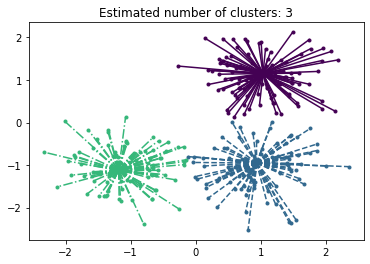

In [16]:
import matplotlib.pyplot as plt

plt.close("all")
plt.figure(1)
plt.clf()

colors = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))
marker = ['-', '--', '-.']
for k, col in zip(range(n_clusters_), colors):
    class_members = labels == k
    cluster_center = X[cluster_centers_indices[k]]
    plt.scatter(X[class_members, 0], X[class_members, 1], color=col["color"], marker=".")
    plt.scatter(cluster_center[0], cluster_center[1], s=14, color=col["color"], marker="o")
    for x in X[class_members]:
        plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], marker[k], color=col["color"])

plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

<div style="text-align: center;">图5-58  Affinity Propagation聚类结果

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>此实验将展示参数如何影响簇数量，验证preference=-50在当前数据中的最优性。该结果验证了AP算法在标准高斯分布数据上的有效性。
</p>

### <font color='blue' >5.7.4  层次聚类</font>

层次聚类是一类通过依次合并或拆分构建嵌套聚类的算法。聚类的层次结构表示为树。树根是汇集所有样本的唯一簇，叶子是只有一个样本的簇。层次聚类的步骤如下：①每个样本点为一个簇；②基于簇联接准则合并簇；③重复步骤②，直到只留下一个簇。由此，就得到了聚类的层次结构。

层次聚类自下而上地执行分层聚类，以下簇联接准则确定了合并策略。

（1）最小化所有簇内的平方差之和（Ward），这是一种方差最小化方法，类似于KMeans算法的目标函数，但它采用了聚集层次方法。

（2）完全联接（Complete），使得簇对中的观测值之间的最大距离最小化。

（3）平均联接（Average），使得簇对中的所有观测值之间的距离的平均值最小化。

（4）单联接（Single），使得簇对中最接近的观测值之间的距离最小化。

当与联接矩阵联合使用时，AgglomerativeClustering可以扩展到大量样本情况，但当样本之间没有联合约束时，计算成本会很高，因为它在每一步都考虑所有可能的合并。

FeatureAggregation将看起来非常相似的特征分成一组，从而减少特征数量。这是一种降维工具。

#### <font color='blue' >5.7.4.1  联接准则</font>

AgglomerativeClustering支持Ward、Single、Average和Complete联接准则。

汇集聚类具有“越富有就越富有”的特点，导致聚类规模不均衡。在这方面，Single联接准则是最糟糕的策略，Ward联接准则给出了最规则的规模。然而，亲和度（或聚类中使用的距离）不能随Ward的变化而变化，因此对于非欧几里得距离度量，Average联接准则可能是一个好的选择。Single联接准则虽然对噪声数据不具有鲁棒性，但可以非常有效地进行计算，因此可用于提供较大规模的数据集的分层聚类。Single联接准则也可以在非球状数据集上表现良好。

**例5-33：在toy数据集上，不同层次联接准则的比较。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 本例展示了在一个“有趣”的二维数据集上进行分层聚类时采用不同联接准则的特点，如图5-59。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 生成数据集。<br /> 
    2. 聚类并绘图。<br /> 
    3. 绘制结果。<br /> 
</details>

主要观察结果有：①Single联接准则速度快，在非球状数据集上表现良好，但在有噪声的情况下表现不佳；②Average和Complete联接准则在干净分离的球状簇上表现良好，但在其他方面结果喜忧参半；③Ward联接准则是处理含噪声数据的最有效的方法。

虽然这个例子给出了一些关于算法的直觉，但这种直觉可能不适用于非常高维的数据。

第一步，生成数据集。这里选择足够大的数据集以查看算法的可扩展性，但不要太大以避免过长的运行时间。

In [18]:
import time
import warnings
from itertools import cycle, islice
import matplotlib.pyplot as plt
import numpy as np
from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# 各向异性分布数据
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)

第二步，聚类并绘图。

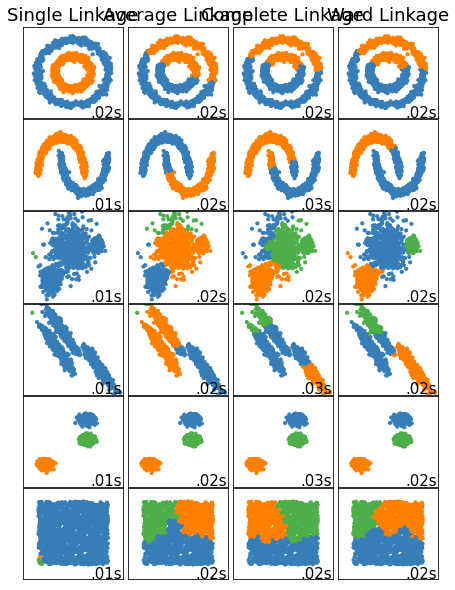

In [20]:
# 设置聚类参数
plt.figure(figsize=(6, 8)) 
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.001, top=0.96, wspace=0.05, hspace=0.01)

plot_num = 1
default_base = {"n_neighbors": 10, "n_clusters": 3}

datasets = [
    (noisy_circles, {"n_clusters": 2}), (noisy_moons, {"n_clusters": 2}),
    (varied, {"n_neighbors": 2}), (aniso, {"n_neighbors": 2}), (blobs, {}), (no_structure, {}),]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset
    X = StandardScaler().fit_transform(X)

    ward = cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="ward")
    complete = cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="complete")
    average = cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="average")
    single = cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="single")

    clustering_algorithms = (
        ("Single Linkage", single),
        ("Average Linkage", average),
        ("Complete Linkage", complete),
        ("Ward Linkage", ward),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()
        
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="the number of connected components of the "
                + "connectivity matrix is [0-9]{1,2} > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            algorithm.fit(X)

        t1 = time.time()
        y_pred = algorithm.labels_.astype(int) if hasattr(algorithm, "labels_") else algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(list(islice(cycle(
            ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"]),
            int(max(y_pred) + 1)
        )))
        
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(0.99, 0.01, ("%.2fs" % (t1 - t0)).lstrip("0"),
                transform=plt.gca().transAxes, size=15, horizontalalignment="right")
        plot_num += 1

plt.show()

<div style="text-align: center;">图5-59  层次聚类不同联接准则的效果

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>该实验揭示了层次聚类在不同数据拓扑结构中的表现边界，为选择聚类算法提供了重要参考：对于复杂形状数据应优先考虑DBSCAN或谱聚类，而标准球形簇场景Ward方法仍是首选。后续改进可尝试结合层次聚类与密度聚类构建混合模型。
</p>

#### <font color='blue' >5.7.4.2  层次聚类的可视化</font>

将簇的层次合并可视化为一个树状图。视觉观察通常有助于我们理解数据集结构，在样本量较小的情况下可能更为有用。

**例5-34：绘制层次聚类树状图。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 这段代码展示了如何使用 AgglomerativeClustering（层次聚类）对鸢尾花数据集进行聚类分析，并通过树状图（Dendrogram）可视化聚类过程。代码的目标是通过树状图展示层次聚类的合并过程，帮助理解不同样本之间的相似度和聚类的层次结构。
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 加载数据集。<br /> 
    2. 层次聚类。<br /> 
    3. 绘制树状图。<br /> 
    4. 可视化。<br /> 
</details>

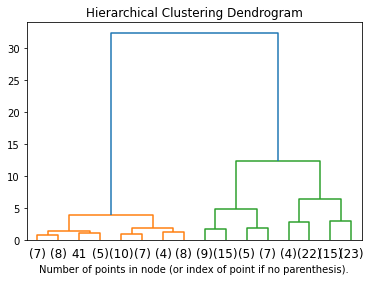

In [14]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris

def plot_dendrogram(model, **kwargs):
    # 构建连接矩阵并绘制树状图

    # 创建在每个节点上的样本数
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    dendrogram(linkage_matrix, **kwargs)  # 绘制相应的树状图

iris = load_iris()
X = iris.data

# 设置 distance_threshold=0 以确保计算完整的树。
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model, truncate_mode="level", p=3)  # 树状图前三个层
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

><p style="line-height: 1.8;">
<font color='blue'>结果解析</font><br>通过层次聚类对鸢尾花数据集进行分析并绘制树状图，清晰地展示了数据的层次结构和聚类过程。树状图揭示了样本之间的相似度和合并顺序，帮助理解不同层次的聚类结果。观察树状图可以直观地选择合适的距离阈值或簇数量，从而确定最佳的聚类方案。此外，树状图的层次性也表明了层次聚类在处理复杂数据结构时的优势，尤其是在选择合适的簇数量方面非常有帮助。
</p>

### <font color='blue' >5.7.5  DBSCAN</font>

<font color='red'>DBSCAN</font>是一个基于密度的算法，它将样本点的密集区域组成一个簇。DBSCAN算法将聚类视为由低密度区域分隔的高密度区域。在该观点下，DBSCAN发现的聚类可以是任何形状，而KMeans假设聚类是凸的。DBSCAN的核心组成部分是核心样本的概念，核心样本是位于高密度区域的样本。因此，聚类由一组相互靠近的核心样本（通过某种距离测量）和一组靠近核心样本的非核心样本（但本身不是核心样本）组成。该算法有两个参数，min_samples和eps，它们正式定义了我们所说的稠密的含义。较高的min_samples或较低的eps表示形成一个簇所需的较高密度。

更正式地说，我们将核心样本定义为数据集中的样本，在eps的距离内至少存在min_samples个其他样本，这些其他样本被定义为核心样本的邻居。这告诉我们，核心样本应在样本空间的密集区域。一个聚类由一组核心样本组成，可以递归地获取核心样本，其由找到的所有为核心样本的邻居来构建。聚类还有一组非核心样本，这些样本是簇中核心样本的邻居，但其本身不是核心样本。直观地说，这些样本位于簇的边缘。

根据定义，任何核心样本都是聚类的一部分。任何不是核心样本的样本和与任何核心样本之间的距离至少为eps的样本都被算法视为异常值。

虽然参数min_samples主要控制算法对噪声的容忍度（在含噪声的大数据集上，可能需要增加该参数），但参数eps对于数据集和距离函数的适当选择至关重要，通常不会一直使用默认值，它控制点集的局部邻域，如果选择得太小，则大多数数据将根本不会进行聚类（标记为-1，表示噪声）；如果选择得太大，则会导致封闭的簇合并到一个聚类中，并最终将整个数据集作为单个簇返回。

**例5-35：DBSCAN聚类算法展示。**
><details>
   <summary><font color='blue'>问题描述</font></summary>
 DBSCAN在高密度区域中找到核心样本，并扩展聚类。该算法适用于包含相似密度的簇的数据
</details>

><details>
    <summary><font color='blue'>算法步骤</font></summary>
    1. 生成数据。。<br /> 
    2. 生成数据标准化后可视化。<br /> 
    3. 执行DBSCAN。<br /> 
    4. 绘制结果。<br /> 
</details>

第一步，生成数据。

这里使用make_blobs()函数构建3个合成的簇。

In [24]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(n_samples=750, centers=centers, cluster_std=0.4, random_state=0)

X = StandardScaler().fit_transform(X)

第二步，生成数据标准化后可视化，如图5-61所示。

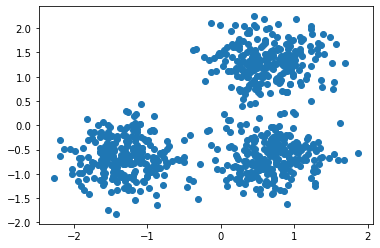

In [25]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

<div style="text-align: center;">图5-61  生成数据标准化后可视化

第三步，执行DBSCAN。

可以使用labels_属性访问DBSCAN分配的标签。噪声样本的标签为-1。

In [26]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_
# 标签中的簇数，忽略噪声（如果存在）
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


聚类算法基本上是<font color='red'>无监督学习方法</font>。然而，由于make_blobs()可以访问合成聚类的真实标签，因此可以利用这种“监督”的真实值信息来量化生成聚类的质量。在此，使用的评估指标可以有同质性、完整性、V-测度、兰德指数、调整后兰德指数和调整后互信息（AMI）等。

如果真值标签未知，则只能使用模型结果本身进行评估。在这种情况下，轮廓系数就派上了用场。

In [27]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print("Adjusted Mutual Information:" f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


第四步，绘制结果。

核心样本（大点）和非核心样本（小点）依据指定的聚类进行颜色编码。标记为噪波的样本以黑色表示，如图5-62所示。

In [28]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # 黑点表示噪声